# Projeto 2 — Previsão do tempo médio de espera na urgência

Este notebook tem como objetivo desenvolver uma primeira abordagem preditiva para estimar o tempo médio diário de espera entre a triagem e a primeira observação médica na rede de urgência hospitalar.

A análise parte da tabela nacional previamente preparada no Projeto 1.

Nesta fase, o foco será:

- definir corretamente o problema preditivo;
- preparar a série temporal nacional;
- criar variáveis explicativas sem usar informação futura;
- construir modelos simples de referência;
- avaliar o desempenho dos modelos com métricas apropriadas.

O objetivo é demonstrar um fluxo técnico rigoroso de preparação, modelação e avaliação.

In [1]:
# Permite trabalhar com caminhos de ficheiros e pastas de forma robusta
from pathlib import Path

# Biblioteca principal para leitura, preparação e análise de dados
import pandas as pd

# Biblioteca para criação de gráficos
import matplotlib.pyplot as plt

In [2]:
# Define a pasta onde estão guardados os dados processados no Projeto 1
DATA_PROCESSED = Path("../data/processed")

# Define o caminho para o ficheiro nacional preparado
nacional_path = DATA_PROCESSED / "monitorizacao_sazonal_csh_nacional.csv"

# Confirma se o ficheiro existe
nacional_path.exists()

True

In [3]:
# Lê a tabela nacional preparada no Projeto 1
# A coluna "periodo" é convertida diretamente para datetime
df = pd.read_csv(
    nacional_path,
    sep=";",
    parse_dates=["periodo"]
)

# Mostra as primeiras linhas para validar o carregamento
df.head()

,periodo,regiao_ars,ano,mes,ano_mes,estado_ano,episodios_urgencia,prioridade_verde_azul,taxa_internamento,tempo_medio_espera,tipo_agregacao
0,2016-11-01,Portugal Continental,2016,11,2016-11,parcial,15067.0,39.72250,8.901787,48.78547,nacional
1,2016-11-02,Portugal Continental,2016,11,2016-11,parcial,17941.0,41.16970,8.100157,56.54435,nacional
2,2016-11-03,Portugal Continental,2016,11,2016-11,parcial,17449.0,40.85881,8.452868,57.67384,nacional
3,2016-11-04,Portugal Continental,2016,11,2016-11,parcial,16253.0,40.60996,9.118156,54.10371,nacional
4,2016-11-05,Portugal Continental,2016,11,2016-11,parcial,14153.0,39.46748,9.564175,44.60065,nacional


In [4]:
# Mostra a dimensão da tabela carregada
print(f"Número de linhas: {df.shape[0]}")
print(f"Número de colunas: {df.shape[1]}")

# Mostra o período temporal disponível
print(f"Período: {df['periodo'].min()} a {df['periodo'].max()}")

# Mostra as colunas disponíveis
df.columns.tolist()

Número de linhas: 3473
Número de colunas: 11
Período: 2016-11-01 00:00:00 a 2026-05-09 00:00:00


['periodo',
 'regiao_ars',
 'ano',
 'mes',
 'ano_mes',
 'estado_ano',
 'episodios_urgencia',
 'prioridade_verde_azul',
 'taxa_internamento',
 'tempo_medio_espera',
 'tipo_agregacao']

In [5]:
# Confirma os tipos de dados de cada coluna
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3473 entries, 0 to 3472
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   periodo                3473 non-null   datetime64[us]
 1   regiao_ars             3473 non-null   str           
 2   ano                    3473 non-null   int64         
 3   mes                    3473 non-null   int64         
 4   ano_mes                3473 non-null   str           
 5   estado_ano             3473 non-null   str           
 6   episodios_urgencia     3473 non-null   float64       
 7   prioridade_verde_azul  3473 non-null   float64       
 8   taxa_internamento      3473 non-null   float64       
 9   tempo_medio_espera     3473 non-null   float64       
 10  tipo_agregacao         3473 non-null   str           
dtypes: datetime64[us](1), float64(4), int64(2), str(4)
memory usage: 298.6 KB


## 2. Definição do problema preditivo

O objetivo deste notebook é prever o valor diário do indicador `tempo_medio_espera`, que representa o tempo médio de espera entre a triagem e a primeira observação médica na rede de urgência hospitalar.

A unidade de análise será o dia, considerando apenas o agregado nacional de Portugal Continental.

A variável-alvo será:

`tempo_medio_espera`

As restantes variáveis disponíveis poderão ser usadas como variáveis explicativas, desde que respeitem uma regra fundamental:

> Nenhuma variável pode usar informação futura relativamente ao dia que se pretende prever.

Nesta primeira versão, o objetivo não é obter o melhor modelo possível, mas construir uma abordagem preditiva simples, interpretável e tecnicamente correta.

In [6]:
# Ordena os dados por data
# Em problemas temporais, a ordem cronológica dos registos é essencial
df = df.sort_values("periodo").reset_index(drop=True)

# Define a variável-alvo do problema preditivo
target = "tempo_medio_espera"

# Confirma a cobertura temporal da variável-alvo
print(f"Primeira data: {df['periodo'].min()}")
print(f"Última data: {df['periodo'].max()}")

# Conta valores nulos na variável-alvo
print(f"\nValores nulos em {target}: {df[target].isna().sum()}")

# Mostra estatísticas descritivas da variável-alvo
df[target].describe()

Primeira data: 2016-11-01 00:00:00
Última data: 2026-05-09 00:00:00

Valores nulos em tempo_medio_espera: 0


count    3473.00000
mean       61.24694
std        14.04369
min        24.54189
25%        51.52370
50%        60.64650
75%        69.88574
max       161.40000
Name: tempo_medio_espera, dtype: float64

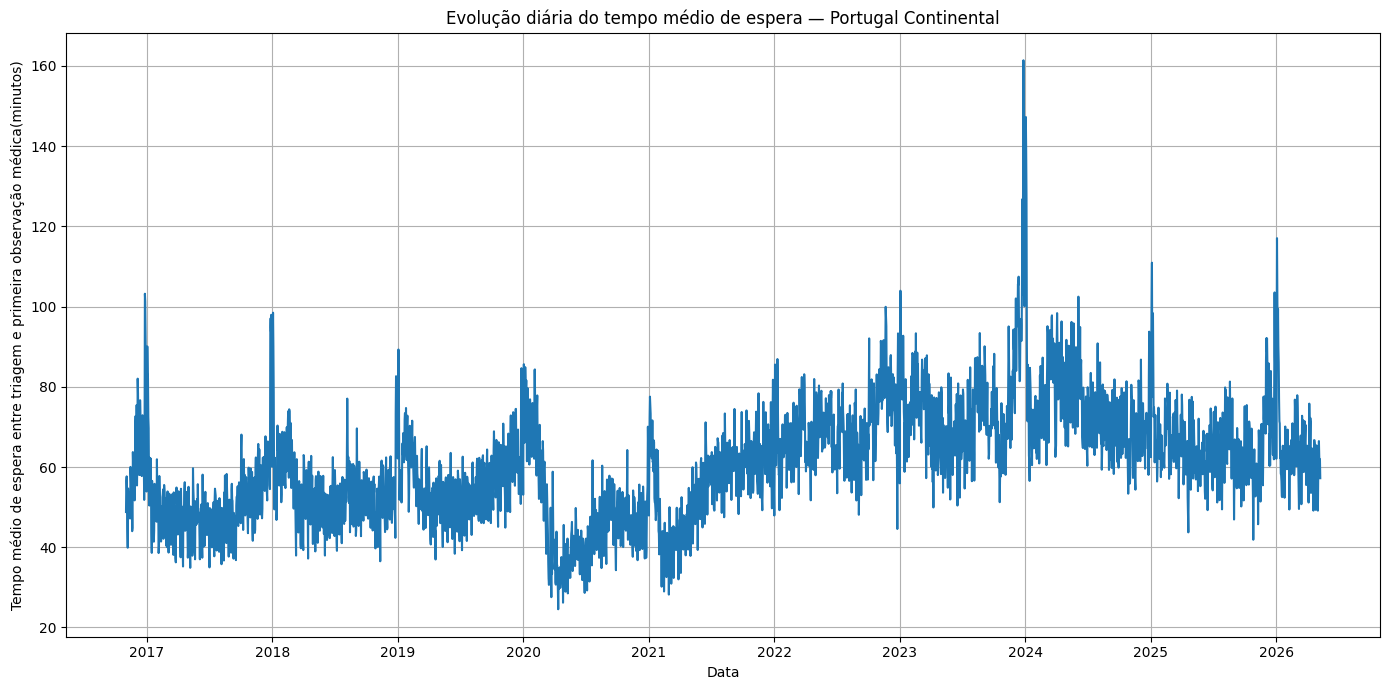

In [7]:
# Cria uma visualização simples da evolução diária da variável-alvo
# Esta análise ajuda a perceber tendência, sazonalidade e períodos de maior instabilidade
plt.figure(figsize=(14, 7))

plt.plot(
    df["periodo"],
    df[target]
)

plt.title("Evolução diária do tempo médio de espera — Portugal Continental")
plt.xlabel("Data")
plt.ylabel("Tempo médio de espera entre triagem e primeira observação médica(minutos)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [8]:
# Verifica se existem datas duplicadas na série nacional
# Para modelação temporal, esperamos uma única linha por dia
duplicados_periodo = df.duplicated(subset=["periodo"]).sum()

print(f"Número de datas duplicadas: {duplicados_periodo}")

# Verifica se existem falhas temporais na sequência diária
datas_esperadas = pd.date_range(
    start=df["periodo"].min(),
    end=df["periodo"].max(),
    freq="D"
)

datas_existentes = pd.DatetimeIndex(df["periodo"])

datas_em_falta = datas_esperadas.difference(datas_existentes)

print(f"Número de datas em falta: {len(datas_em_falta)}")

# Mostra as primeiras datas em falta, caso existam
datas_em_falta[:10]

Número de datas duplicadas: 0
Número de datas em falta: 4


DatetimeIndex(['2025-02-04', '2025-02-05', '2025-02-06', '2025-02-07'], dtype='datetime64[us]', freq='D')

## 3. Preparação da série temporal para modelação

A série nacional não apresenta datas duplicadas, mas tem quatro dias em falta em fevereiro de 2025.

Para modelação temporal, é importante manter a estrutura diária completa. Caso contrário, o modelo poderia interpretar erradamente dias separados por uma falha como se fossem consecutivos.

Nesta etapa será criada uma série diária contínua entre a primeira e a última data disponíveis. As datas sem registo serão mantidas com valores nulos, sem imputação nesta fase.

In [9]:
# Cria uma cópia da tabela nacional para preparação da série temporal
df_ts = df.copy()

# Garante que os dados estão ordenados cronologicamente
df_ts = df_ts.sort_values("periodo").reset_index(drop=True)

# Define o período como índice para permitir a reconstrução da série diária
df_ts = df_ts.set_index("periodo")

# Cria um índice diário contínuo entre a primeira e a última data disponível
indice_diario = pd.date_range(
    start=df_ts.index.min(),
    end=df_ts.index.max(),
    freq="D"
)

# Reindexa a tabela para garantir uma linha por dia
# As datas originalmente em falta passam a existir como linhas com valores nulos
df_ts = df_ts.reindex(indice_diario)

# Devolve o índice temporal a uma coluna chamada "periodo"
df_ts = df_ts.reset_index().rename(columns={"index": "periodo"})

# Recria variáveis temporais a partir da data
# Isto evita depender de valores em falta nas linhas criadas pela reindexação
df_ts["ano"] = df_ts["periodo"].dt.year
df_ts["mes"] = df_ts["periodo"].dt.month
df_ts["ano_mes"] = df_ts["periodo"].dt.to_period("M").astype(str)
df_ts["dia_semana"] = df_ts["periodo"].dt.dayofweek

# Repõe a identificação da agregação nacional
df_ts["regiao_ars"] = "Portugal Continental"
df_ts["tipo_agregacao"] = "nacional"


# Define novamente a classificação da cobertura anual
# Esta função é necessária neste notebook porque ele é independente do notebook 1
def classificar_estado_ano(ano):
    if ano in [2016, 2026]:
        return "parcial"
    elif ano == 2025:
        return "completo_com_falhas"
    else:
        return "completo"


# Recria a classificação do estado do ano
df_ts["estado_ano"] = df_ts["ano"].apply(classificar_estado_ano)

# Mostra as primeiras linhas da série temporal preparada
df_ts.head()

,periodo,regiao_ars,ano,mes,ano_mes,estado_ano,episodios_urgencia,prioridade_verde_azul,taxa_internamento,tempo_medio_espera,tipo_agregacao,dia_semana
0,2016-11-01,Portugal Continental,2016,11,2016-11,parcial,15067.0,39.72250,8.901787,48.78547,nacional,1
1,2016-11-02,Portugal Continental,2016,11,2016-11,parcial,17941.0,41.16970,8.100157,56.54435,nacional,2
2,2016-11-03,Portugal Continental,2016,11,2016-11,parcial,17449.0,40.85881,8.452868,57.67384,nacional,3
3,2016-11-04,Portugal Continental,2016,11,2016-11,parcial,16253.0,40.60996,9.118156,54.10371,nacional,4
4,2016-11-05,Portugal Continental,2016,11,2016-11,parcial,14153.0,39.46748,9.564175,44.60065,nacional,5


In [10]:
# Confirma a dimensão da série temporal após reindexação
print(f"Número de linhas após reindexação: {df_ts.shape[0]}")

# Confirma se continuam a existir datas duplicadas
print(f"Datas duplicadas: {df_ts.duplicated(subset=['periodo']).sum()}")

# Confirma os valores nulos por coluna após a criação das datas em falta
df_ts.isna().sum()

Número de linhas após reindexação: 3477
Datas duplicadas: 0


periodo                  0
regiao_ars               0
ano                      0
mes                      0
ano_mes                  0
estado_ano               0
episodios_urgencia       4
prioridade_verde_azul    4
taxa_internamento        4
tempo_medio_espera       4
tipo_agregacao           0
dia_semana               0
dtype: int64

## 4. Criação de variáveis explicativas

Nesta etapa serão criadas variáveis para modelação preditiva.

Como se trata de uma série temporal, as variáveis explicativas devem respeitar a ordem cronológica dos dados.

Para evitar fuga de informação, não serão usados valores do próprio dia para prever o tempo médio de espera desse mesmo dia. Em vez disso, serão criadas variáveis com valores passados, como:

- valor do dia anterior;
- valor da semana anterior;
- médias móveis de períodos anteriores;
- variáveis de calendário.

Desta forma, cada previsão usa apenas informação que estaria disponível antes do dia a prever.

In [11]:
# Cria uma cópia da série temporal para construção das variáveis de modelação
df_features = df_ts.copy()

# Garante que a tabela está ordenada por data
df_features = df_features.sort_values("periodo").reset_index(drop=True)

# Define a variável-alvo
target = "tempo_medio_espera"

# Cria variáveis de calendário
# Estas variáveis são conhecidas antecipadamente e não representam fuga de informação
df_features["dia_do_mes"] = df_features["periodo"].dt.day
df_features["dia_do_ano"] = df_features["periodo"].dt.dayofyear
df_features["semana_ano"] = df_features["periodo"].dt.isocalendar().week.astype(int)

# Cria variáveis indicadoras para fim de semana
df_features["fim_de_semana"] = df_features["dia_semana"].isin([5, 6]).astype(int)

# Mostra as primeiras linhas com as novas variáveis de calendário
df_features[
    [
        "periodo",
        "ano",
        "mes",
        "dia_semana",
        "dia_do_mes",
        "dia_do_ano",
        "semana_ano",
        "fim_de_semana",
        target
    ]
].head()

,periodo,ano,mes,dia_semana,dia_do_mes,dia_do_ano,semana_ano,fim_de_semana,tempo_medio_espera
0,2016-11-01,2016,11,1,1,306,44,0,48.78547
1,2016-11-02,2016,11,2,2,307,44,0,56.54435
2,2016-11-03,2016,11,3,3,308,44,0,57.67384
3,2016-11-04,2016,11,4,4,309,44,0,54.10371
4,2016-11-05,2016,11,5,5,310,44,1,44.60065


In [12]:
# Define os indicadores que serão usados para criar variáveis baseadas em valores passados
indicadores_lag = [
    "tempo_medio_espera",
    "episodios_urgencia",
    "prioridade_verde_azul",
    "taxa_internamento"
]

# Define os atrasos temporais a criar
# lag_1: valor do dia anterior
# lag_7: valor do mesmo dia da semana anterior
# lag_14: valor de duas semanas antes
lags = [1, 7, 14]

# Cria variáveis de lag para cada indicador
for indicador in indicadores_lag:
    for lag in lags:
        df_features[f"{indicador}_lag_{lag}"] = df_features[indicador].shift(lag)

# Mostra algumas das variáveis criadas para a variável-alvo
df_features[
    [
        "periodo",
        target,
        "tempo_medio_espera_lag_1",
        "tempo_medio_espera_lag_7",
        "tempo_medio_espera_lag_14"
    ]
].head(20)

,periodo,tempo_medio_espera,tempo_medio_espera_lag_1,tempo_medio_espera_lag_7,tempo_medio_espera_lag_14
0,2016-11-01,48.78547,NaN,NaN,NaN
1,2016-11-02,56.54435,48.78547,NaN,NaN
2,2016-11-03,57.67384,56.54435,NaN,NaN
3,2016-11-04,54.10371,57.67384,NaN,NaN
4,2016-11-05,44.60065,54.10371,NaN,NaN
5,2016-11-06,39.88894,44.60065,NaN,NaN
6,2016-11-07,54.66299,39.88894,NaN,NaN
7,2016-11-08,48.00844,54.66299,48.78547,NaN
8,2016-11-09,49.77863,48.00844,56.54435,NaN
9,2016-11-10,53.43503,49.77863,57.67384,NaN


In [13]:
# Cria médias móveis da variável-alvo usando apenas valores anteriores ao dia observado
# O shift(1) garante que o valor do próprio dia não entra no cálculo
df_features["tempo_medio_espera_media_movel_7"] = (
    df_features[target]
    .shift(1)
    .rolling(window=7, min_periods=7)
    .mean()
)

df_features["tempo_medio_espera_media_movel_14"] = (
    df_features[target]
    .shift(1)
    .rolling(window=14, min_periods=14)
    .mean()
)

df_features["tempo_medio_espera_media_movel_28"] = (
    df_features[target]
    .shift(1)
    .rolling(window=28, min_periods=28)
    .mean()
)

# Mostra as médias móveis criadas
df_features[
    [
        "periodo",
        target,
        "tempo_medio_espera_media_movel_7",
        "tempo_medio_espera_media_movel_14",
        "tempo_medio_espera_media_movel_28"
    ]
].head(35)

,periodo,tempo_medio_espera,tempo_medio_espera_media_movel_7,tempo_medio_espera_media_movel_14,tempo_medio_espera_media_movel_28
0,2016-11-01,48.78547,NaN,NaN,NaN
1,2016-11-02,56.54435,NaN,NaN,NaN
2,2016-11-03,57.67384,NaN,NaN,NaN
3,2016-11-04,54.10371,NaN,NaN,NaN
4,2016-11-05,44.60065,NaN,NaN,NaN
5,2016-11-06,39.88894,NaN,NaN,NaN
6,2016-11-07,54.66299,NaN,NaN,NaN
7,2016-11-08,48.00844,50.894279,NaN,NaN
8,2016-11-09,49.77863,50.783274,NaN,NaN
9,2016-11-10,53.43503,49.816743,NaN,NaN


In [14]:
# Confirma a dimensão da tabela com features
print(f"Número de linhas: {df_features.shape[0]}")
print(f"Número de colunas: {df_features.shape[1]}")

# Mostra as colunas criadas
df_features.columns.tolist()

Número de linhas: 3477
Número de colunas: 31


['periodo',
 'regiao_ars',
 'ano',
 'mes',
 'ano_mes',
 'estado_ano',
 'episodios_urgencia',
 'prioridade_verde_azul',
 'taxa_internamento',
 'tempo_medio_espera',
 'tipo_agregacao',
 'dia_semana',
 'dia_do_mes',
 'dia_do_ano',
 'semana_ano',
 'fim_de_semana',
 'tempo_medio_espera_lag_1',
 'tempo_medio_espera_lag_7',
 'tempo_medio_espera_lag_14',
 'episodios_urgencia_lag_1',
 'episodios_urgencia_lag_7',
 'episodios_urgencia_lag_14',
 'prioridade_verde_azul_lag_1',
 'prioridade_verde_azul_lag_7',
 'prioridade_verde_azul_lag_14',
 'taxa_internamento_lag_1',
 'taxa_internamento_lag_7',
 'taxa_internamento_lag_14',
 'tempo_medio_espera_media_movel_7',
 'tempo_medio_espera_media_movel_14',
 'tempo_medio_espera_media_movel_28']

## 5. Preparação do dataset de modelação

Após a criação das variáveis explicativas, algumas linhas passam a ter valores nulos.

Isto acontece por três motivos principais:

- os primeiros dias da série não têm valores anteriores suficientes para calcular `lags`;
- as médias móveis precisam de vários dias anteriores para serem calculadas;
- existem quatro dias sem registo original em fevereiro de 2025.

Nesta etapa será criada uma tabela final de modelação, mantendo apenas as linhas com informação suficiente para treino e avaliação dos modelos.

In [15]:
# Conta os valores nulos por coluna após a criação das variáveis explicativas
# Esta validação permite perceber que variáveis perderam observações
nulos_features = df_features.isna().sum()

# Mostra apenas as colunas que têm valores nulos
nulos_features[nulos_features > 0].sort_values(ascending=False)

tempo_medio_espera_media_movel_28    59
tempo_medio_espera_media_movel_14    31
tempo_medio_espera_lag_14            18
taxa_internamento_lag_14             18
prioridade_verde_azul_lag_14         18
episodios_urgencia_lag_14            18
tempo_medio_espera_media_movel_7     17
tempo_medio_espera_lag_7             11
prioridade_verde_azul_lag_7          11
taxa_internamento_lag_7              11
episodios_urgencia_lag_7             11
tempo_medio_espera_lag_1              5
prioridade_verde_azul_lag_1           5
taxa_internamento_lag_1               5
episodios_urgencia_lag_1              5
taxa_internamento                     4
prioridade_verde_azul                 4
episodios_urgencia                    4
tempo_medio_espera                    4
dtype: int64

In [16]:
# Mostra as linhas em torno das datas em falta de fevereiro de 2025
# Esta validação permite observar o impacto das falhas nos lags e médias móveis
df_features[
    (df_features["periodo"] >= "2025-01-25") &
    (df_features["periodo"] <= "2025-02-15")
][
    [
        "periodo",
        "tempo_medio_espera",
        "tempo_medio_espera_lag_1",
        "tempo_medio_espera_lag_7",
        "tempo_medio_espera_media_movel_7",
        "episodios_urgencia",
        "episodios_urgencia_lag_1"
    ]
]

,periodo,tempo_medio_espera,tempo_medio_espera_lag_1,tempo_medio_espera_lag_7,tempo_medio_espera_media_movel_7,episodios_urgencia,episodios_urgencia_lag_1
3007,2025-01-25,66.9605,73.2879,65.2579,66.859600,15523.0,16791.0
3008,2025-01-26,62.0073,66.9605,56.3942,67.102829,14108.0,15523.0
3009,2025-01-27,63.3850,62.0073,59.0354,67.904700,17515.0,14108.0
3010,2025-01-28,70.6610,63.3850,67.3921,68.526071,17159.0,17515.0
3011,2025-01-29,65.2839,70.6610,71.8470,68.993057,16252.0,17159.0
3012,2025-01-30,57.4801,65.2839,74.8027,68.055471,16156.0,16252.0
3013,2025-01-31,62.7270,57.4801,73.2879,65.580814,15973.0,16156.0
3014,2025-02-01,67.9054,62.7270,66.9605,64.072114,14549.0,15973.0
3015,2025-02-02,59.2661,67.9054,62.0073,64.207100,13763.0,14549.0
3016,2025-02-03,63.6483,59.2661,63.3850,63.815500,17547.0,13763.0


In [17]:
# Define a variável-alvo
target = "tempo_medio_espera"

# Define as variáveis explicativas que serão usadas na primeira versão do modelo
# Incluem apenas variáveis de calendário e informação passada
features = [
    "ano",
    "mes",
    "dia_semana",
    "dia_do_mes",
    "dia_do_ano",
    "semana_ano",
    "fim_de_semana",
    
    "tempo_medio_espera_lag_1",
    "tempo_medio_espera_lag_7",
    "tempo_medio_espera_lag_14",
    "tempo_medio_espera_media_movel_7",
    "tempo_medio_espera_media_movel_14",
    "tempo_medio_espera_media_movel_28",
    
    "episodios_urgencia_lag_1",
    "episodios_urgencia_lag_7",
    "episodios_urgencia_lag_14",
    
    "prioridade_verde_azul_lag_1",
    "prioridade_verde_azul_lag_7",
    "prioridade_verde_azul_lag_14",
    
    "taxa_internamento_lag_1",
    "taxa_internamento_lag_7",
    "taxa_internamento_lag_14"
]

# Cria uma tabela apenas com período, features e target
df_model = df_features[
    ["periodo"] + features + [target]
].copy()

# Remove linhas com valores nulos
# Estas linhas não têm informação suficiente para treino ou avaliação
df_model = df_model.dropna().reset_index(drop=True)

# Confirma a dimensão final do dataset de modelação
print(f"Número de linhas em df_features: {df_features.shape[0]}")
print(f"Número de linhas em df_model: {df_model.shape[0]}")
print(f"Número de linhas removidas: {df_features.shape[0] - df_model.shape[0]}")

# Confirma se ainda existem valores nulos
print(f"\nValores nulos restantes: {df_model.isna().sum().sum()}")

# Mostra as primeiras linhas do dataset final de modelação
df_model.head()

Número de linhas em df_features: 3477
Número de linhas em df_model: 3417
Número de linhas removidas: 60

Valores nulos restantes: 0


,periodo,ano,mes,dia_semana,dia_do_mes,dia_do_ano,semana_ano,fim_de_semana,tempo_medio_espera_lag_1,tempo_medio_espera_lag_7,...,episodios_urgencia_lag_1,episodios_urgencia_lag_7,episodios_urgencia_lag_14,prioridade_verde_azul_lag_1,prioridade_verde_azul_lag_7,prioridade_verde_azul_lag_14,taxa_internamento_lag_1,taxa_internamento_lag_7,taxa_internamento_lag_14,tempo_medio_espera
0,2016-11-29,2016,11,1,29,334,48,0,70.24299,59.74539,...,20010.0,17914.0,17560.0,40.15193,41.07761,40.68982,7.787510,8.670556,8.465476,72.72624
1,2016-11-30,2016,11,2,30,335,48,0,72.72624,58.20954,...,18683.0,17342.0,16872.0,39.81942,40.77323,40.94414,8.713186,8.764533,8.441769,62.11633
2,2016-12-01,2016,12,3,1,336,48,0,62.11633,61.85072,...,17541.0,16518.0,17162.0,40.63177,39.38221,39.66042,9.189857,8.401010,8.464400,57.71897
3,2016-12-02,2016,12,4,2,337,48,0,57.71897,56.78054,...,16449.0,15659.0,16018.0,40.14273,39.44028,39.54499,8.222904,8.763776,9.223370,75.44713
4,2016-12-03,2016,12,5,3,338,48,1,75.44713,51.69221,...,18584.0,15091.0,14586.0,40.56549,38.23951,39.69954,8.282567,9.896441,8.692278,55.41006


## 6. Divisão temporal entre treino e teste

Nesta etapa, o dataset de modelação será dividido em treino e teste.

Como se trata de uma série temporal, a divisão não será aleatória. Os dados mais antigos serão usados para treino e os dados mais recentes serão usados para teste.

Esta abordagem simula melhor o cenário real, em que um modelo é treinado com dados históricos e depois aplicado a períodos futuros.

Nesta primeira versão, serão usados dados até ao final de 2024 para treino e dados a partir de 2025 para teste.

In [18]:
# Define a data de corte entre treino e teste
# Dados anteriores a 2025 serão usados para treino
# Dados a partir de 2025 serão usados para teste
data_corte = pd.Timestamp("2025-01-01")

# Cria o conjunto de treino com os dados históricos
df_train = df_model[
    df_model["periodo"] < data_corte
].copy()

# Cria o conjunto de teste com os dados mais recentes
df_test = df_model[
    df_model["periodo"] >= data_corte
].copy()

# Separa as variáveis explicativas e a variável-alvo no conjunto de treino
X_train = df_train[features]
y_train = df_train[target]

# Separa as variáveis explicativas e a variável-alvo no conjunto de teste
X_test = df_test[features]
y_test = df_test[target]

# Confirma a dimensão dos conjuntos criados
print(f"Linhas de treino: {df_train.shape[0]}")
print(f"Linhas de teste: {df_test.shape[0]}")

print(f"\nPeríodo de treino: {df_train['periodo'].min()} a {df_train['periodo'].max()}")
print(f"Período de teste: {df_test['periodo'].min()} a {df_test['periodo'].max()}")

print(f"\nDimensão X_train: {X_train.shape}")
print(f"Dimensão X_test: {X_test.shape}")

Linhas de treino: 2955
Linhas de teste: 462

Período de treino: 2016-11-29 00:00:00 a 2024-12-31 00:00:00
Período de teste: 2025-01-01 00:00:00 a 2026-05-09 00:00:00

Dimensão X_train: (2955, 22)
Dimensão X_test: (462, 22)


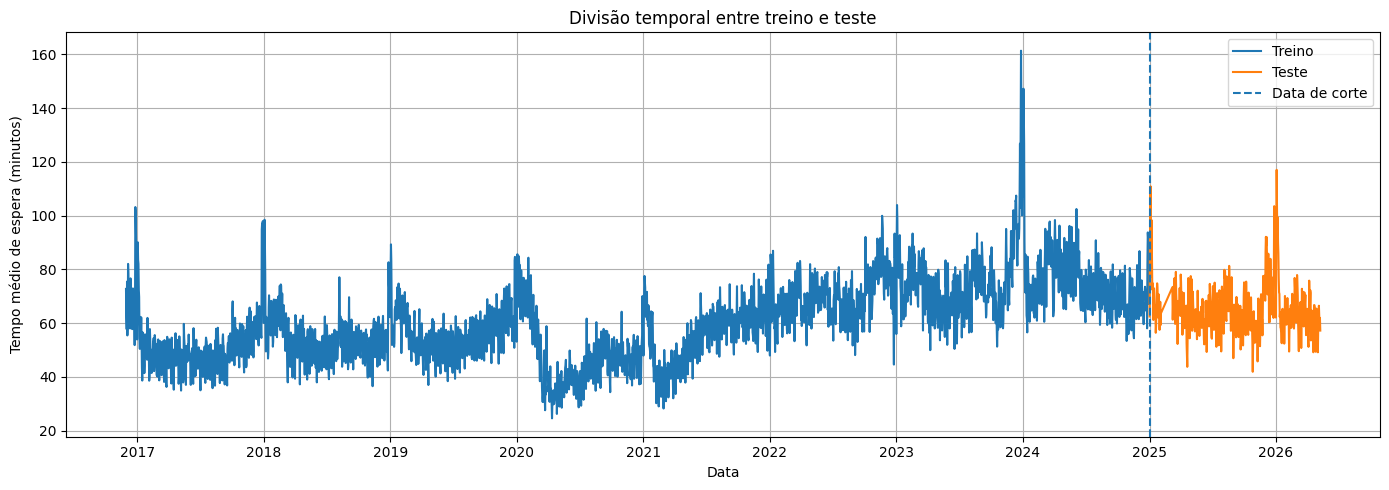

In [19]:
# Visualiza a divisão temporal entre treino e teste
# Esta figura permite confirmar que o teste corresponde ao período mais recente da série
plt.figure(figsize=(14, 5))

plt.plot(
    df_train["periodo"],
    df_train[target],
    label="Treino"
)

plt.plot(
    df_test["periodo"],
    df_test[target],
    label="Teste"
)

plt.axvline(
    data_corte,
    linestyle="--",
    label="Data de corte"
)

plt.title("Divisão temporal entre treino e teste")
plt.xlabel("Data")
plt.ylabel("Tempo médio de espera (minutos)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

A divisão temporal entre treino e teste foi realizada com corte em 2025-01-01.

Os dados anteriores a 2025 foram usados para treino, enquanto os dados de 2025 e 2026 foram reservados para teste. Esta abordagem evita mistura temporal entre observações antigas e recentes, simulando um cenário mais realista de previsão futura.

O conjunto de treino começa em 2016-11-29 porque as primeiras observações foram removidas após a criação de variáveis com lags e médias móveis, nomeadamente a média móvel de 28 dias.

Visualmente, observa-se que o período de treino inclui fases com comportamentos distintos da série, incluindo períodos de maior estabilidade, quedas acentuadas e picos de espera mais elevados. O período de teste apresenta valores recentes da série, permitindo avaliar se os modelos conseguem generalizar para dados posteriores ao período usado no treino.

## 7. Modelo baseline

Antes de treinar modelos de Machine Learning, é necessário criar um modelo de referência simples.

O baseline permite perceber qual o erro obtido por uma regra muito simples de previsão.

Nesta primeira abordagem, serão testados três baselines:

- prever o valor de hoje com o valor do dia anterior;
- prever o valor de hoje com o valor da semana anterior;
- prever o valor de hoje com a média móvel dos 7 dias anteriores.

Estes baselines não usam informação futura e servem como referência mínima para avaliar os modelos seguintes.

In [20]:
# Cria uma tabela com os valores reais e as previsões baseline no conjunto de teste
df_baseline = df_test[
    [
        "periodo",
        target,
        "tempo_medio_espera_lag_1",
        "tempo_medio_espera_lag_7",
        "tempo_medio_espera_media_movel_7"
    ]
].copy()

# Renomeia as colunas dos baselines para tornar a leitura mais clara
df_baseline = df_baseline.rename(columns={
    target: "valor_real",
    "tempo_medio_espera_lag_1": "baseline_dia_anterior",
    "tempo_medio_espera_lag_7": "baseline_semana_anterior",
    "tempo_medio_espera_media_movel_7": "baseline_media_7_dias"
})

# Mostra as primeiras linhas da tabela de baselines
df_baseline.head()

,periodo,valor_real,baseline_dia_anterior,baseline_semana_anterior,baseline_media_7_dias
2955,2025-01-01,62.4545,81.8932,58.0461,78.807114
2956,2025-01-02,86.5522,62.4545,82.3358,79.436886
2957,2025-01-03,102.7310,86.5522,93.7480,80.039229
2958,2025-01-04,110.9420,102.7310,91.2771,81.322514
2959,2025-01-05,86.7138,110.9420,77.1920,84.131786


In [21]:
# Define uma função simples para calcular métricas de erro
# MAE: erro médio absoluto, em minutos
# RMSE: penaliza mais os erros grandes
def calcular_metricas(y_real, y_predito):
    erro = y_real - y_predito
    
    mae = erro.abs().mean()
    rmse = ((erro ** 2).mean()) ** 0.5
    
    return mae, rmse


# Calcula as métricas para cada baseline
metricas_baseline = []

for coluna_baseline in [
    "baseline_dia_anterior",
    "baseline_semana_anterior",
    "baseline_media_7_dias"
]:
    mae, rmse = calcular_metricas(
        df_baseline["valor_real"],
        df_baseline[coluna_baseline]
    )
    
    metricas_baseline.append({
        "modelo": coluna_baseline,
        "MAE": mae,
        "RMSE": rmse
    })

# Cria uma tabela com as métricas dos baselines
df_metricas_baseline = pd.DataFrame(metricas_baseline)

# Ordena os resultados pelo MAE, do menor erro para o maior
df_metricas_baseline = df_metricas_baseline.sort_values("MAE").reset_index(drop=True)

# Mostra a comparação dos baselines
df_metricas_baseline

,modelo,MAE,RMSE
0,baseline_media_7_dias,6.011422,7.856003
1,baseline_dia_anterior,6.234793,7.940093
2,baseline_semana_anterior,6.474657,9.030688


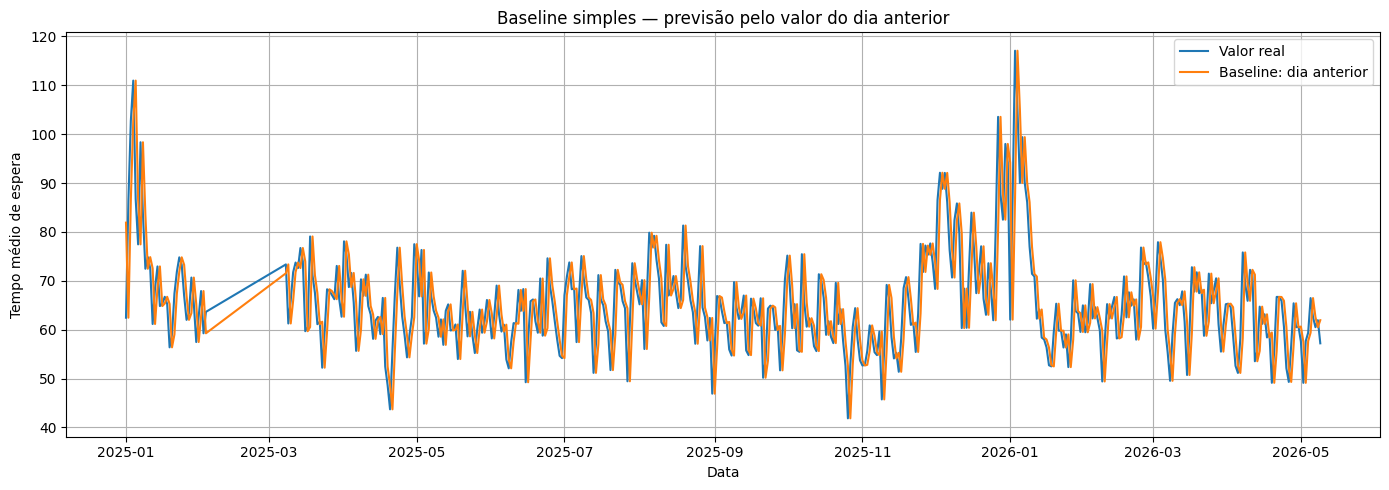

In [22]:
# Visualiza o valor real face ao melhor baseline simples: valor do dia anterior
plt.figure(figsize=(14, 5))

plt.plot(
    df_baseline["periodo"],
    df_baseline["valor_real"],
    label="Valor real"
)

plt.plot(
    df_baseline["periodo"],
    df_baseline["baseline_dia_anterior"],
    label="Baseline: dia anterior"
)

plt.title("Baseline simples — previsão pelo valor do dia anterior")
plt.xlabel("Data")
plt.ylabel("Tempo médio de espera")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Interpretação dos baselines

O melhor baseline foi a previsão baseada na média móvel dos 7 dias anteriores, com um MAE de aproximadamente 6,0 minutos e um RMSE de aproximadamente 7,9 minutos.

Isto significa que, sem treinar ainda qualquer modelo de Machine Learning, uma regra simples baseada no histórico recente consegue prever o tempo médio de espera diário com um erro médio absoluto de cerca de 6 minutos.

Este valor será usado como referência mínima para os modelos seguintes. Um modelo preditivo mais complexo só acrescentará valor se conseguir obter um erro inferior ao melhor baseline.

## 8. Modelo de regressão linear

Após a criação dos baselines, será treinado um primeiro modelo supervisionado de regressão.

Nesta etapa será usada uma regressão linear com normalização das variáveis explicativas através de `StandardScaler`.

A regressão linear serve como primeiro modelo de Machine Learning por ser simples, interpretável e adequada como ponto de comparação inicial.

O objetivo é verificar se um modelo treinado com várias variáveis históricas e de calendário consegue melhorar o desempenho obtido pelo melhor baseline.

In [23]:
# Importa as ferramentas necessárias para criar o primeiro modelo de regressão
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

# Cria um pipeline com normalização das features e regressão linear
# O StandardScaler coloca as variáveis numa escala comparável
# A regressão linear aprende a relação entre as features e o tempo médio de espera
modelo_regressao_linear = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

# Treina o modelo usando apenas o conjunto de treino
modelo_regressao_linear.fit(X_train, y_train)

# Gera previsões para o conjunto de teste
y_pred_lr = modelo_regressao_linear.predict(X_test)

# Calcula as métricas do modelo
mae_lr, rmse_lr = calcular_metricas(
    y_test,
    pd.Series(y_pred_lr, index=y_test.index)
)

print(f"MAE Regressão Linear: {mae_lr:.3f}")
print(f"RMSE Regressão Linear: {rmse_lr:.3f}")

MAE Regressão Linear: 4.431
RMSE Regressão Linear: 6.050


In [24]:
# Cria uma tabela com o resultado do modelo de regressão linear
df_metricas_lr = pd.DataFrame([
    {
        "modelo": "regressao_linear",
        "MAE": mae_lr,
        "RMSE": rmse_lr
    }
])

# Junta os resultados dos baselines com o modelo de regressão linear
df_comparacao_modelos = pd.concat(
    [
        df_metricas_baseline,
        df_metricas_lr
    ],
    ignore_index=True
)

# Ordena os modelos pelo MAE, do menor erro para o maior
df_comparacao_modelos = df_comparacao_modelos.sort_values("MAE").reset_index(drop=True)

# Mostra a comparação final até ao momento
df_comparacao_modelos

,modelo,MAE,RMSE
0,regressao_linear,4.430974,6.049873
1,baseline_media_7_dias,6.011422,7.856003
2,baseline_dia_anterior,6.234793,7.940093
3,baseline_semana_anterior,6.474657,9.030688


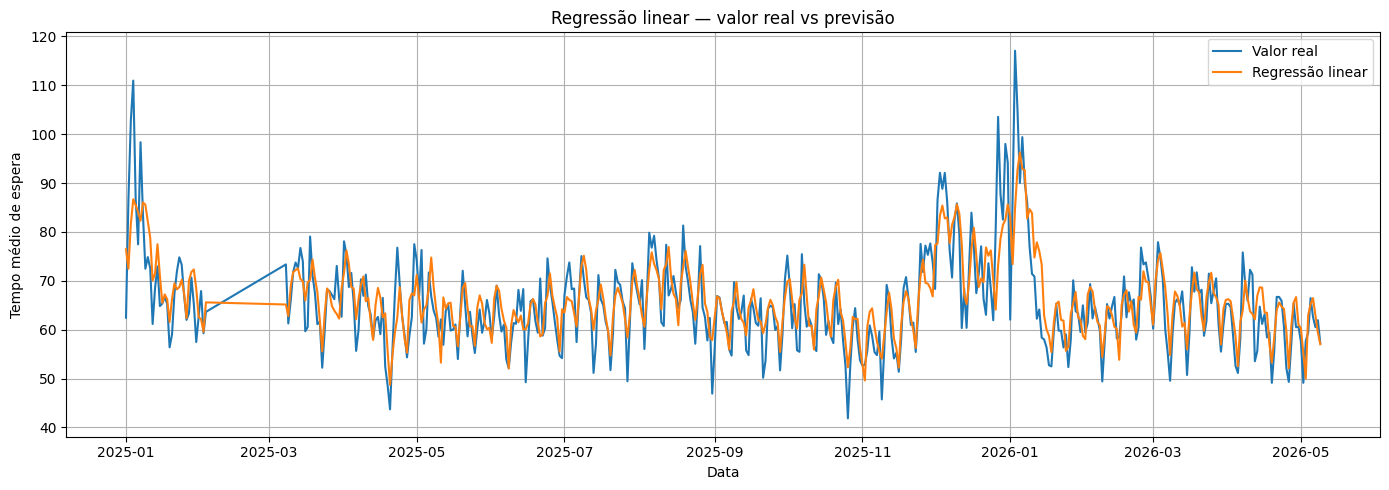

In [25]:
# Cria uma tabela com valores reais e previsões da regressão linear
df_resultados_lr = df_test[["periodo", target]].copy()

df_resultados_lr["previsao_regressao_linear"] = y_pred_lr

# Visualiza o valor real face à previsão da regressão linear
plt.figure(figsize=(14, 5))

plt.plot(
    df_resultados_lr["periodo"],
    df_resultados_lr[target],
    label="Valor real"
)

plt.plot(
    df_resultados_lr["periodo"],
    df_resultados_lr["previsao_regressao_linear"],
    label="Regressão linear"
)

plt.title("Regressão linear — valor real vs previsão")
plt.xlabel("Data")
plt.ylabel("Tempo médio de espera")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Interpretação da regressão linear

A regressão linear obteve melhor desempenho do que todos os modelos baseline avaliados.

O MAE diminuiu de aproximadamente 6,0 minutos no melhor baseline para cerca de 4,4 minutos na regressão linear. Isto indica que a combinação de variáveis históricas, médias móveis e variáveis de calendário acrescentou capacidade preditiva face a uma regra simples baseada apenas no histórico recente.

Apesar deste resultado positivo, a avaliação não deve ficar limitada às métricas globais. É necessário analisar os erros ao longo do tempo para perceber se o modelo falha sobretudo em períodos de maior instabilidade ou em dias com picos de tempo de espera.

## 9. Análise dos erros do modelo

Após avaliar as métricas globais, é importante analisar os erros produzidos pelo modelo.

Esta etapa permite perceber se o modelo falha de forma distribuída ao longo do tempo ou se apresenta erros maiores em períodos específicos, nomeadamente em dias com picos de tempo médio de espera.

A análise dos erros é essencial para interpretar a utilidade prática do modelo e identificar limitações.

In [26]:
# Cria uma tabela com os valores reais, previsões e erros da regressão linear
df_erros_lr = df_resultados_lr.copy()

# Calcula o erro simples
# Erro positivo: valor real maior do que a previsão
# Erro negativo: valor real menor do que a previsão
df_erros_lr["erro"] = df_erros_lr[target] - df_erros_lr["previsao_regressao_linear"]

# Calcula o erro absoluto
df_erros_lr["erro_absoluto"] = df_erros_lr["erro"].abs()

# Mostra estatísticas descritivas dos erros
df_erros_lr[["erro", "erro_absoluto"]].describe()

,erro,erro_absoluto
count,462.000000,462.000000
mean,-0.818368,4.430974
std,6.000765,4.123620
min,-20.951458,0.006685
25%,-4.370762,1.399937
50%,-1.104932,3.494312
75%,2.059729,6.214373
max,32.134520,32.134520


In [27]:
# Identifica os dias com maiores erros absolutos
# Esta análise permite perceber em que datas o modelo teve pior desempenho
df_erros_lr.sort_values(
    "erro_absoluto",
    ascending=False
).head(10)

,periodo,tempo_medio_espera,previsao_regressao_linear,erro,erro_absoluto
3290,2026-01-03,117.0540,84.919480,32.134520,32.134520
3283,2025-12-27,103.5290,73.129264,30.399736,30.399736
2958,2025-01-04,110.9420,86.680724,24.261276,24.261276
2957,2025-01-03,102.7310,81.627606,21.103394,21.103394
3288,2026-01-01,62.0565,83.007958,-20.951458,20.951458
3268,2025-12-12,60.3315,77.536857,-17.205357,17.205357
3282,2025-12-26,80.3048,64.093616,16.211184,16.211184
2961,2025-01-07,98.3352,82.279999,16.055201,16.055201
3299,2026-01-12,62.2542,77.886723,-15.632523,15.632523
3286,2025-12-30,97.9872,82.475252,15.511948,15.511948


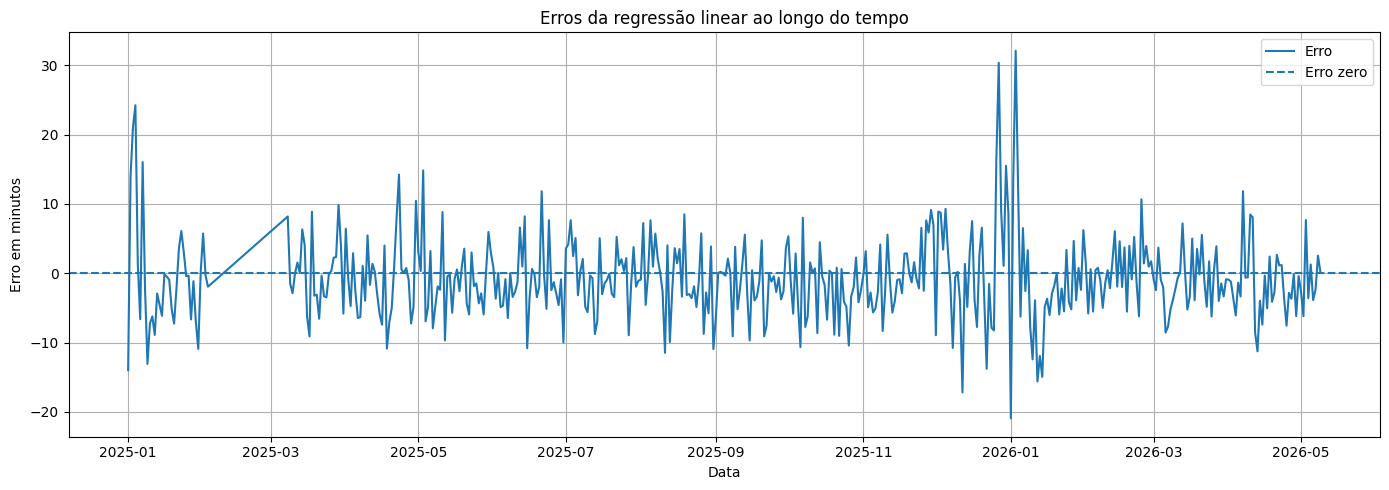

In [28]:
# Visualiza os erros da regressão linear ao longo do tempo
plt.figure(figsize=(14, 5))

plt.plot(
    df_erros_lr["periodo"],
    df_erros_lr["erro"],
    label="Erro"
)

plt.axhline(
    0,
    linestyle="--",
    label="Erro zero"
)

plt.title("Erros da regressão linear ao longo do tempo")
plt.xlabel("Data")
plt.ylabel("Erro em minutos")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

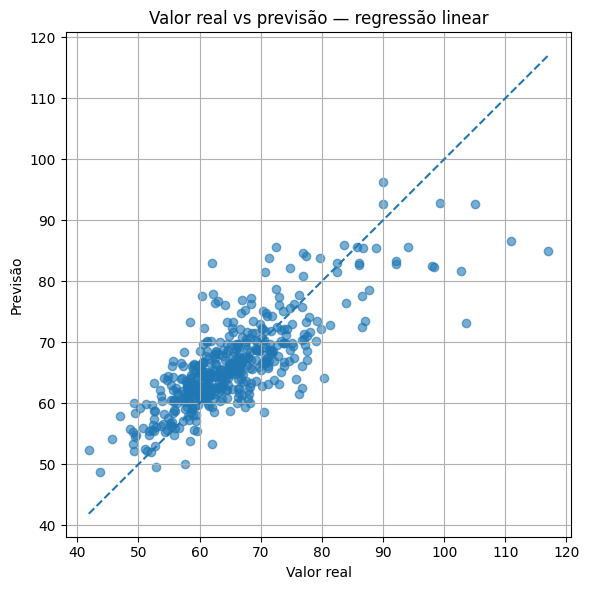

In [29]:
# Visualiza a relação entre valores reais e previsões
# Quanto mais próximos os pontos estiverem da linha diagonal, melhor é a previsão
plt.figure(figsize=(6, 6))

plt.scatter(
    df_erros_lr[target],
    df_erros_lr["previsao_regressao_linear"],
    alpha=0.6
)

plt.plot(
    [
        df_erros_lr[target].min(),
        df_erros_lr[target].max()
    ],
    [
        df_erros_lr[target].min(),
        df_erros_lr[target].max()
    ],
    linestyle="--"
)

plt.title("Valor real vs previsão — regressão linear")
plt.xlabel("Valor real")
plt.ylabel("Previsão")
plt.grid(True)
plt.tight_layout()
plt.show()

### Conclusão técnica da regressão linear

A regressão linear apresentou um desempenho superior aos modelos baseline, reduzindo o erro médio absoluto face à melhor regra simples baseada na média dos 7 dias anteriores.

**Pontos fortes do modelo:**

- melhor desempenho global do que os baselines;
- erro médio absoluto relativamente baixo;
- modelo simples, interpretável e adequado como primeira abordagem supervisionada;
- utilização apenas de variáveis históricas e de calendário, evitando fuga de informação temporal.

**Limitações identificadas:**

- dificuldade em prever picos abruptos do tempo médio de espera;
- tendência para suavizar valores extremos;
- maior erro em períodos de maior instabilidade, sobretudo no início de janeiro de 2025 e no final de dezembro de 2025/início de janeiro de 2026.

Assim, a regressão linear constitui uma primeira referência válida de Machine Learning, mas não deve ser considerada o modelo final. Os resultados justificam a avaliação de modelos mais flexíveis, capazes de captar relações não lineares e comportamentos mais extremos da série.

### Interpretação dos erros da regressão linear

A análise dos erros mostra que a regressão linear apresenta bom desempenho global, mas tem dificuldade em prever valores extremos do tempo médio de espera.

A maioria dos erros encontra-se próxima de zero, o que é coerente com o MAE obtido. No entanto, existem erros mais elevados em períodos específicos, sobretudo no início de janeiro de 2025 e no final de dezembro de 2025/início de janeiro de 2026.

Os maiores erros positivos indicam situações em que o modelo subestimou o tempo médio de espera real. Isto sugere que a regressão linear consegue captar o comportamento médio da série, mas tem menor capacidade para antecipar picos abruptos.

No gráfico entre valores reais e previsões observa-se também que, para valores reais mais elevados, o modelo tende a prever valores mais baixos. Esta limitação é expectável num modelo linear simples e justifica a avaliação posterior de modelos mais flexíveis.

## 10. Random Forest Regressor

Nesta etapa será treinado um modelo `Random Forest Regressor`.

Ao contrário da regressão linear, este modelo consegue captar relações não lineares entre as variáveis explicativas e o tempo médio de espera.

O objetivo é avaliar se um modelo mais flexível consegue melhorar o desempenho da regressão linear, sobretudo em períodos de maior instabilidade.

A divisão temporal entre treino e teste mantém-se inalterada, garantindo que o modelo continua a ser treinado apenas com dados históricos e avaliado em dados futuros.

In [30]:
# Importa o modelo Random Forest para problemas de regressão
from sklearn.ensemble import RandomForestRegressor

# Cria o modelo Random Forest
# random_state garante reprodutibilidade dos resultados
# n_estimators define o número de árvores usadas pelo modelo
modelo_random_forest = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

# Treina o modelo usando apenas o conjunto de treino
modelo_random_forest.fit(X_train, y_train)

# Gera previsões para o conjunto de teste
y_pred_rf = modelo_random_forest.predict(X_test)

# Calcula as métricas do modelo
mae_rf, rmse_rf = calcular_metricas(
    y_test,
    pd.Series(y_pred_rf, index=y_test.index)
)

print(f"MAE Random Forest: {mae_rf:.3f}")
print(f"RMSE Random Forest: {rmse_rf:.3f}")

MAE Random Forest: 4.655
RMSE Random Forest: 6.332


In [31]:
# Cria uma tabela com o resultado do modelo Random Forest
df_metricas_rf = pd.DataFrame([
    {
        "modelo": "random_forest",
        "MAE": mae_rf,
        "RMSE": rmse_rf
    }
])

# Junta os resultados já existentes com o Random Forest
df_comparacao_modelos = pd.concat(
    [
        df_comparacao_modelos,
        df_metricas_rf
    ],
    ignore_index=True
)

# Remove possíveis duplicados caso a célula seja corrida mais do que uma vez
df_comparacao_modelos = (
    df_comparacao_modelos
    .drop_duplicates(subset=["modelo"], keep="last")
    .sort_values("MAE")
    .reset_index(drop=True)
)

# Mostra a comparação dos modelos
df_comparacao_modelos

,modelo,MAE,RMSE
0,regressao_linear,4.430974,6.049873
1,random_forest,4.654810,6.331863
2,baseline_media_7_dias,6.011422,7.856003
3,baseline_dia_anterior,6.234793,7.940093
4,baseline_semana_anterior,6.474657,9.030688


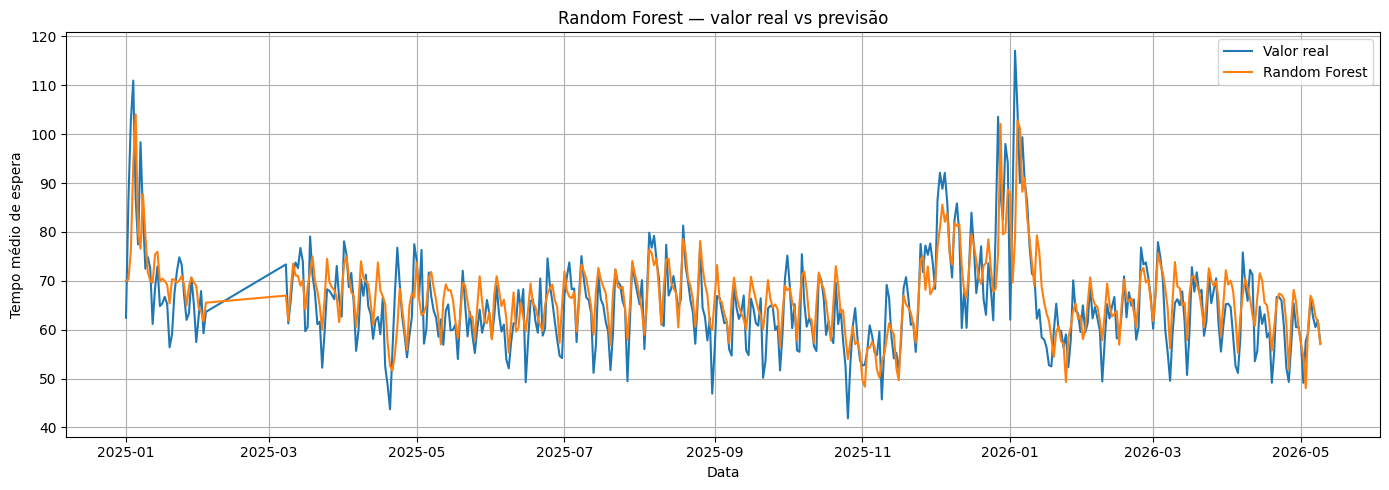

In [32]:
# Cria uma tabela com valores reais e previsões do Random Forest
df_resultados_rf = df_test[["periodo", target]].copy()

df_resultados_rf["previsao_random_forest"] = y_pred_rf

# Visualiza o valor real face à previsão do Random Forest
plt.figure(figsize=(14, 5))

plt.plot(
    df_resultados_rf["periodo"],
    df_resultados_rf[target],
    label="Valor real"
)

plt.plot(
    df_resultados_rf["periodo"],
    df_resultados_rf["previsao_random_forest"],
    label="Random Forest"
)

plt.title("Random Forest — valor real vs previsão")
plt.xlabel("Data")
plt.ylabel("Tempo médio de espera")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [33]:
# Extrai a importância atribuída pelo Random Forest a cada variável explicativa
df_importancia_rf = pd.DataFrame({
    "feature": features,
    "importancia": modelo_random_forest.feature_importances_
})

# Ordena as variáveis pela importância atribuída pelo modelo
df_importancia_rf = (
    df_importancia_rf
    .sort_values("importancia", ascending=False)
    .reset_index(drop=True)
)

# Mostra as 15 variáveis mais importantes
df_importancia_rf.head(15)

,feature,importancia
0,tempo_medio_espera_media_movel_7,0.523454
1,tempo_medio_espera_lag_1,0.189103
2,tempo_medio_espera_lag_7,0.088208
3,tempo_medio_espera_lag_14,0.032249
4,tempo_medio_espera_media_movel_14,0.031125
5,dia_semana,0.019928
6,episodios_urgencia_lag_1,0.015129
7,taxa_internamento_lag_1,0.012542
8,episodios_urgencia_lag_7,0.009722
9,tempo_medio_espera_media_movel_28,0.009610


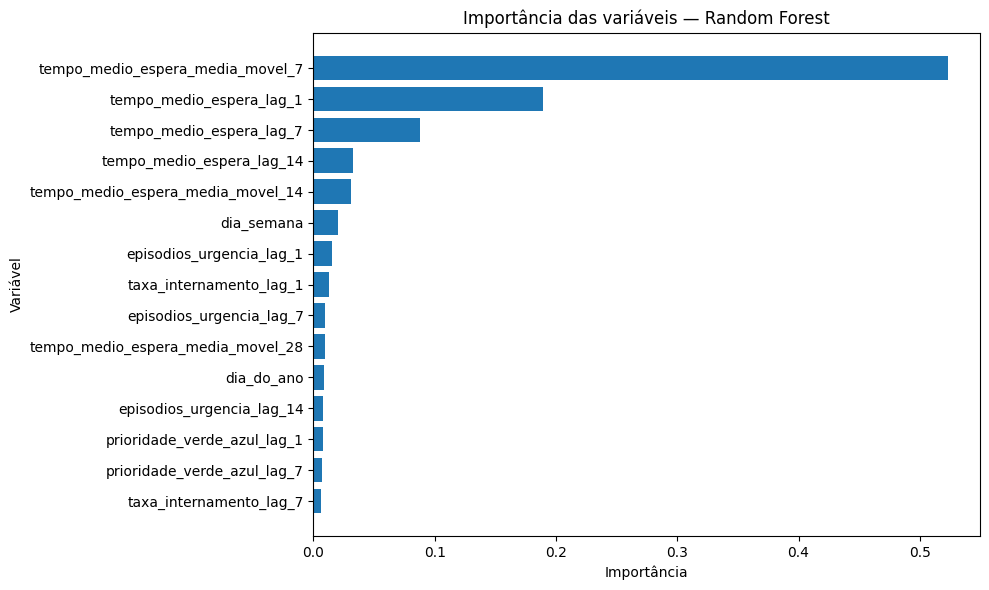

In [34]:
# Visualiza as 15 variáveis mais importantes no Random Forest
top_features_rf = df_importancia_rf.head(15).sort_values("importancia")

plt.figure(figsize=(10, 6))

plt.barh(
    top_features_rf["feature"],
    top_features_rf["importancia"]
)

plt.title("Importância das variáveis — Random Forest")
plt.xlabel("Importância")
plt.ylabel("Variável")
plt.tight_layout()
plt.show()

### Interpretação do Random Forest

O modelo Random Forest apresentou melhor desempenho do que os modelos baseline, mas não superou a regressão linear.

Apesar de ser um modelo mais flexível e capaz de captar relações não lineares, obteve um MAE superior ao da regressão linear. Isto mostra que, neste problema e com este conjunto inicial de variáveis, o aumento da complexidade do modelo não resultou numa melhoria preditiva.

A análise da importância das variáveis mostra que o modelo atribuiu maior relevância ao histórico recente do próprio tempo médio de espera, em particular à média móvel dos 7 dias anteriores e aos valores observados nos dias anteriores. Este resultado é coerente com a natureza temporal do problema.

Assim, o Random Forest confirma a utilidade das variáveis históricas, mas não justifica substituir a regressão linear como melhor modelo nesta fase.

## 11. Análise dos erros do Random Forest

Apesar de o Random Forest não ter superado a regressão linear nas métricas globais, é importante analisar os seus erros.

Esta análise permite perceber se o pior desempenho global resulta de erros distribuídos ao longo do período de teste ou de falhas concentradas em momentos específicos.

A comparação com a regressão linear ajuda também a perceber se o modelo mais flexível melhora algum tipo particular de situação, mesmo não sendo o melhor modelo global.

In [35]:
# Cria uma tabela com os valores reais, previsões e erros do Random Forest
df_erros_rf = df_resultados_rf.copy()

# Calcula o erro simples
# Erro positivo: valor real maior do que a previsão
# Erro negativo: valor real menor do que a previsão
df_erros_rf["erro"] = df_erros_rf[target] - df_erros_rf["previsao_random_forest"]

# Calcula o erro absoluto
df_erros_rf["erro_absoluto"] = df_erros_rf["erro"].abs()

# Mostra estatísticas descritivas dos erros
df_erros_rf[["erro", "erro_absoluto"]].describe()

,erro,erro_absoluto
count,462.000000,462.000000
mean,-1.453025,4.654810
std,6.169570,4.297116
min,-25.615602,0.001340
25%,-4.949789,1.636637
50%,-1.863781,3.695599
75%,1.155412,6.409708
max,38.116650,38.116650


In [36]:
# Identifica os dias com maiores erros absolutos no Random Forest
df_erros_rf.sort_values(
    "erro_absoluto",
    ascending=False
).head(10)

,periodo,tempo_medio_espera,previsao_random_forest,erro,erro_absoluto
3290,2026-01-03,117.0540,78.937350,38.116650,38.116650
3283,2025-12-27,103.5290,75.675487,27.853513,27.853513
2957,2025-01-03,102.7310,76.035805,26.695195,26.695195
3288,2026-01-01,62.0565,87.672102,-25.615602,25.615602
2961,2025-01-07,98.3352,76.560398,21.774802,21.774802
3286,2025-12-30,97.9872,79.906988,18.080212,18.080212
3289,2026-01-02,87.0353,69.641434,17.393866,17.393866
2959,2025-01-05,86.7138,104.061335,-17.347535,17.347535
2958,2025-01-04,110.9420,93.843825,17.098175,17.098175
3299,2026-01-12,62.2542,79.296413,-17.042213,17.042213


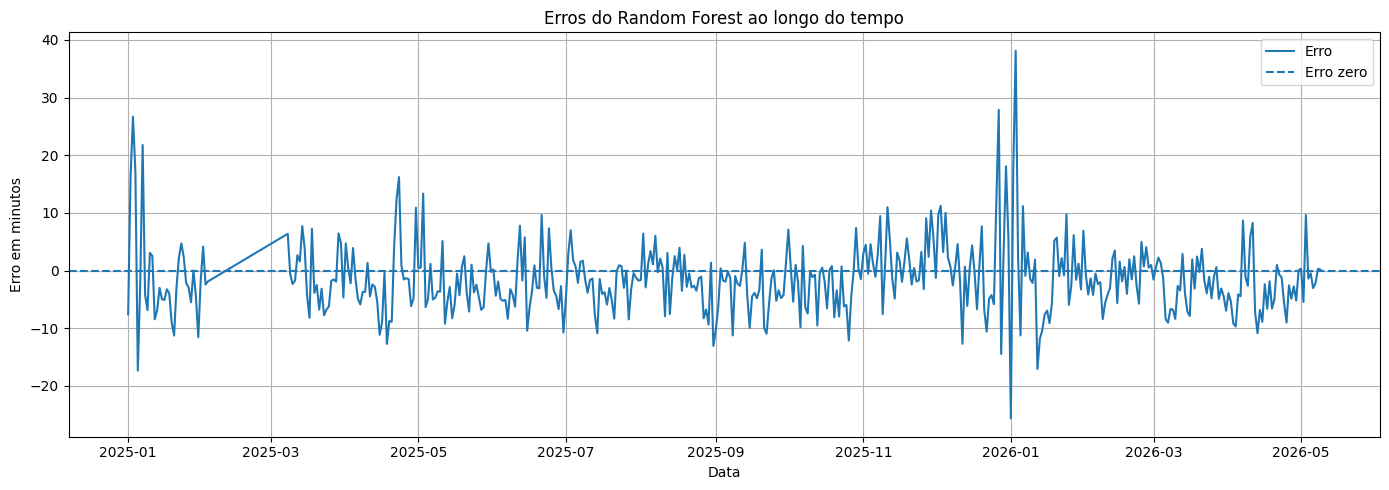

In [37]:
# Visualiza os erros do Random Forest ao longo do tempo
plt.figure(figsize=(14, 5))

plt.plot(
    df_erros_rf["periodo"],
    df_erros_rf["erro"],
    label="Erro"
)

plt.axhline(
    0,
    linestyle="--",
    label="Erro zero"
)

plt.title("Erros do Random Forest ao longo do tempo")
plt.xlabel("Data")
plt.ylabel("Erro em minutos")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

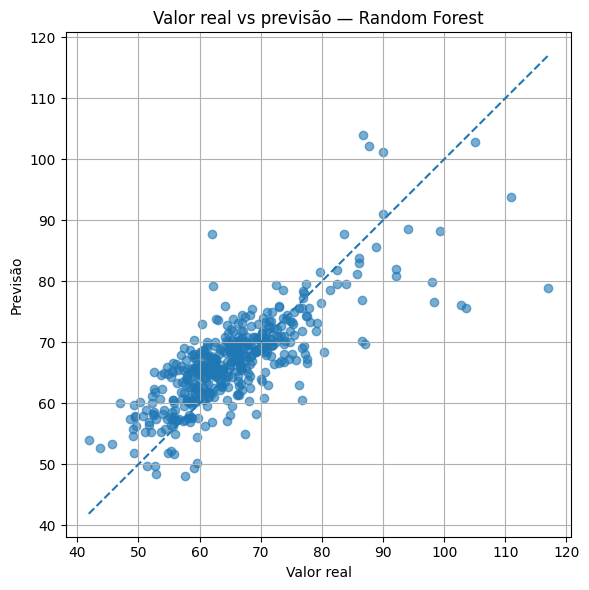

In [38]:
# Visualiza a relação entre valores reais e previsões do Random Forest
# Quanto mais próximos os pontos estiverem da linha diagonal, melhor é a previsão
plt.figure(figsize=(6, 6))

plt.scatter(
    df_erros_rf[target],
    df_erros_rf["previsao_random_forest"],
    alpha=0.6
)

plt.plot(
    [
        df_erros_rf[target].min(),
        df_erros_rf[target].max()
    ],
    [
        df_erros_rf[target].min(),
        df_erros_rf[target].max()
    ],
    linestyle="--"
)

plt.title("Valor real vs previsão — Random Forest")
plt.xlabel("Valor real")
plt.ylabel("Previsão")
plt.grid(True)
plt.tight_layout()
plt.show()

In [39]:
# Compara os erros absolutos da regressão linear e do Random Forest no mesmo período de teste
df_comparacao_erros = df_test[["periodo", target]].copy()

df_comparacao_erros["erro_abs_regressao_linear"] = df_erros_lr["erro_absoluto"].values
df_comparacao_erros["erro_abs_random_forest"] = df_erros_rf["erro_absoluto"].values

# Diferença positiva: Random Forest teve mais erro do que a regressão linear
# Diferença negativa: Random Forest teve menos erro do que a regressão linear
df_comparacao_erros["diferenca_erro_rf_vs_lr"] = (
    df_comparacao_erros["erro_abs_random_forest"] -
    df_comparacao_erros["erro_abs_regressao_linear"]
)

df_comparacao_erros.describe()

,periodo,tempo_medio_espera,erro_abs_regressao_linear,erro_abs_random_forest,diferenca_erro_rf_vs_lr
count,462,462.000000,462.000000,462.000000,462.000000
mean,2025-09-18 03:28:49.870129,65.401401,4.430974,4.654810,0.223836
min,2025-01-01 00:00:00,41.872800,0.006685,0.001340,-10.295653
25%,2025-05-28 06:00:00,59.387250,1.399937,1.636637,-1.317205
50%,2025-09-20 12:00:00,64.374250,3.494312,3.695599,0.189868
75%,2026-01-13 18:00:00,70.050350,6.214373,6.409708,1.801275
max,2026-05-09 00:00:00,117.054000,32.134520,38.116650,16.088958
std,NaN,9.790796,4.123620,4.297116,2.732542


In [40]:
# Conta em quantos dias cada modelo teve menor erro absoluto
dias_lr_melhor = (
    df_comparacao_erros["erro_abs_regressao_linear"] <
    df_comparacao_erros["erro_abs_random_forest"]
).sum()

dias_rf_melhor = (
    df_comparacao_erros["erro_abs_random_forest"] <
    df_comparacao_erros["erro_abs_regressao_linear"]
).sum()

dias_empate = (
    df_comparacao_erros["erro_abs_regressao_linear"] ==
    df_comparacao_erros["erro_abs_random_forest"]
).sum()

print(f"Dias em que a regressão linear teve menor erro: {dias_lr_melhor}")
print(f"Dias em que o Random Forest teve menor erro: {dias_rf_melhor}")
print(f"Dias com empate: {dias_empate}")

Dias em que a regressão linear teve menor erro: 246
Dias em que o Random Forest teve menor erro: 216
Dias com empate: 0


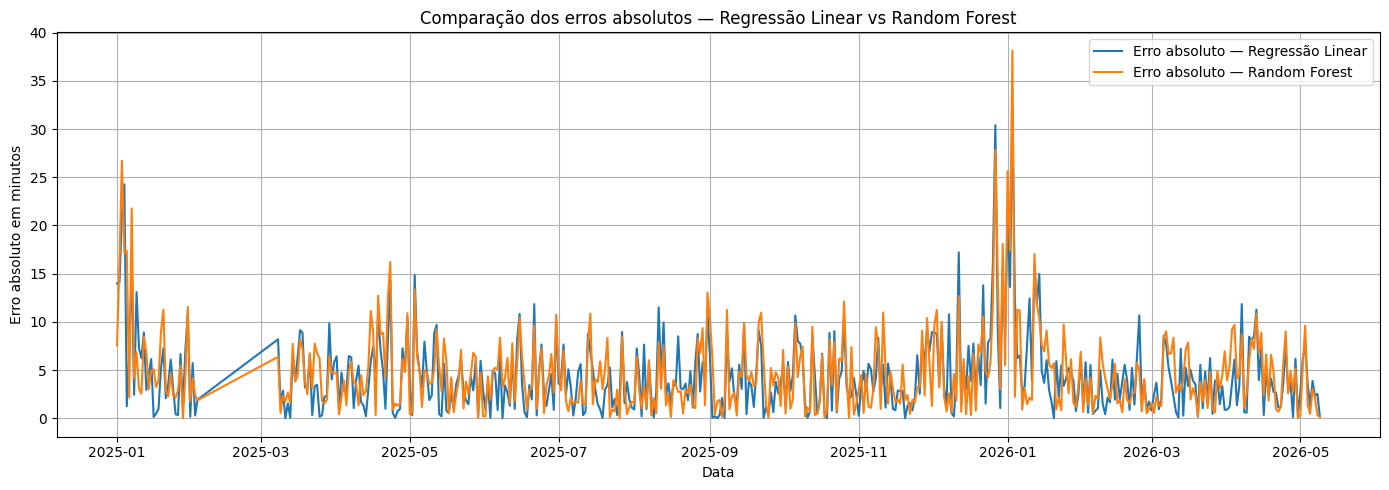

In [41]:
# Visualiza a comparação dos erros absolutos entre os dois modelos
plt.figure(figsize=(14, 5))

plt.plot(
    df_comparacao_erros["periodo"],
    df_comparacao_erros["erro_abs_regressao_linear"],
    label="Erro absoluto — Regressão Linear"
)

plt.plot(
    df_comparacao_erros["periodo"],
    df_comparacao_erros["erro_abs_random_forest"],
    label="Erro absoluto — Random Forest"
)

plt.title("Comparação dos erros absolutos — Regressão Linear vs Random Forest")
plt.xlabel("Data")
plt.ylabel("Erro absoluto em minutos")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Comparação preliminar dos erros entre regressão linear e Random Forest

A comparação dos erros absolutos no conjunto de teste mostra que a regressão linear apresentou menor erro do que o Random Forest em 246 dias, enquanto o Random Forest teve menor erro em 216 dias.

Embora a diferença não seja muito elevada, a regressão linear manteve melhor desempenho global, com MAE e RMSE inferiores. Além disso, o erro absoluto máximo observado no Random Forest foi superior ao da regressão linear.

A análise gráfica sugere que ambos os modelos têm dificuldade em prever valores extremos do tempo médio de espera. O Random Forest, apesar de ser mais flexível, não eliminou a tendência para falhar em períodos de maior instabilidade.

Por este motivo, a regressão linear continua a ser o melhor modelo global até ao momento. No entanto, será ainda relevante avaliar especificamente o comportamento dos modelos nos dias de maior pressão, para perceber se algum deles apresenta melhor desempenho nos extremos da distribuição.

## 12. Comparação dos modelos em dias de maior pressão

A comparação global mostrou que a regressão linear teve melhor desempenho médio do que o Random Forest.

No entanto, em contexto operacional, os dias com tempos médios de espera mais elevados podem ter maior relevância prática do que os dias estáveis.

Por esse motivo, será feita uma análise específica dos dias de maior pressão. Nesta análise, consideram-se dias de pico os dias do conjunto de teste em que o tempo médio de espera é igual ou superior ao percentil 90 observado no conjunto de treino.

Este critério evita definir o limiar com base no próprio período de teste.

In [42]:
# Cria uma tabela única com valores reais e previsões dos dois modelos
df_comparacao_picos = df_test[["periodo", target]].copy()

df_comparacao_picos["previsao_regressao_linear"] = y_pred_lr
df_comparacao_picos["previsao_random_forest"] = y_pred_rf

# Calcula erros absolutos da regressão linear
df_comparacao_picos["erro_abs_regressao_linear"] = (
    df_comparacao_picos[target] -
    df_comparacao_picos["previsao_regressao_linear"]
).abs()

# Calcula erros absolutos do Random Forest
df_comparacao_picos["erro_abs_random_forest"] = (
    df_comparacao_picos[target] -
    df_comparacao_picos["previsao_random_forest"]
).abs()

# Define o limiar de pico a partir do percentil 90 do treino
limiar_pico = y_train.quantile(0.90)

print(f"Limiar de pico: {limiar_pico:.2f} minutos")

# Filtra os dias de teste considerados dias de pico
df_picos = df_comparacao_picos[
    df_comparacao_picos[target] >= limiar_pico
].copy()

print(f"Número de dias de pico no teste: {df_picos.shape[0]}")

df_picos.head()

Limiar de pico: 79.20 minutos
Número de dias de pico no teste: 31


,periodo,tempo_medio_espera,previsao_regressao_linear,previsao_random_forest,erro_abs_regressao_linear,erro_abs_random_forest
2956,2025-01-02,86.5522,72.469265,70.236982,14.082935,16.315218
2957,2025-01-03,102.7310,81.627606,76.035805,21.103394,26.695195
2958,2025-01-04,110.9420,86.680724,93.843825,24.261276,17.098175
2959,2025-01-05,86.7138,85.455223,104.061335,1.258577,17.347535
2961,2025-01-07,98.3352,82.279999,76.560398,16.055201,21.774802


In [43]:
# Compara as métricas dos modelos no teste completo e nos dias de pico
metricas_picos = []

for modelo, coluna_previsao in [
    ("regressao_linear", "previsao_regressao_linear"),
    ("random_forest", "previsao_random_forest")
]:
    mae_global, rmse_global = calcular_metricas(
        df_comparacao_picos[target],
        df_comparacao_picos[coluna_previsao]
    )
    
    mae_picos, rmse_picos = calcular_metricas(
        df_picos[target],
        df_picos[coluna_previsao]
    )
    
    metricas_picos.append({
        "modelo": modelo,
        "MAE_global": mae_global,
        "RMSE_global": rmse_global,
        "MAE_picos": mae_picos,
        "RMSE_picos": rmse_picos
    })

df_metricas_picos = pd.DataFrame(metricas_picos)

df_metricas_picos

,modelo,MAE_global,RMSE_global,MAE_picos,RMSE_picos
0,regressao_linear,4.430974,6.049873,9.822513,12.766495
1,random_forest,4.654810,6.331863,10.592861,13.928127


In [44]:
# Conta em quantos dias de pico cada modelo teve menor erro absoluto
dias_pico_lr_melhor = (
    df_picos["erro_abs_regressao_linear"] <
    df_picos["erro_abs_random_forest"]
).sum()

dias_pico_rf_melhor = (
    df_picos["erro_abs_random_forest"] <
    df_picos["erro_abs_regressao_linear"]
).sum()

dias_pico_empate = (
    df_picos["erro_abs_regressao_linear"] ==
    df_picos["erro_abs_random_forest"]
).sum()

print(f"Dias de pico em que a regressão linear teve menor erro: {dias_pico_lr_melhor}")
print(f"Dias de pico em que o Random Forest teve menor erro: {dias_pico_rf_melhor}")
print(f"Dias de pico com empate: {dias_pico_empate}")

Dias de pico em que a regressão linear teve menor erro: 18
Dias de pico em que o Random Forest teve menor erro: 13
Dias de pico com empate: 0


In [45]:
# Diferença positiva: Random Forest teve mais erro do que a regressão linear
# Diferença negativa: Random Forest teve menos erro do que a regressão linear
df_picos["diferenca_erro_rf_vs_lr"] = (
    df_picos["erro_abs_random_forest"] -
    df_picos["erro_abs_regressao_linear"]
)

# Dias de pico em que o Random Forest foi claramente melhor
df_picos.sort_values(
    "diferenca_erro_rf_vs_lr"
)[
    [
        "periodo",
        target,
        "previsao_regressao_linear",
        "previsao_random_forest",
        "erro_abs_regressao_linear",
        "erro_abs_random_forest",
        "diferenca_erro_rf_vs_lr"
    ]
].head(10)

,periodo,tempo_medio_espera,previsao_regressao_linear,previsao_random_forest,erro_abs_regressao_linear,erro_abs_random_forest,diferenca_erro_rf_vs_lr
3291,2026-01-04,105.0400,92.633086,102.818171,12.406914,2.221829,-10.185086
2958,2025-01-04,110.9420,86.680724,93.843825,24.261276,17.098175,-7.163101
3153,2025-08-19,81.3037,72.799290,78.566674,8.504410,2.737026,-5.767384
3282,2025-12-26,80.3048,64.093616,68.369432,16.211184,11.935368,-4.275816
3139,2025-08-05,79.8387,72.198655,76.442396,7.640045,3.396304,-4.243742
3272,2025-12-16,83.9382,76.406377,79.574859,7.531823,4.363341,-3.168482
3287,2025-12-31,94.1617,85.616058,88.647577,8.545642,5.514123,-3.031519
3283,2025-12-27,103.5290,73.129264,75.675487,30.399736,27.853513,-2.546223
3267,2025-12-11,79.6670,83.748177,81.535131,4.081177,1.868131,-2.213046
3294,2026-01-07,90.0583,92.630499,90.964343,2.572199,0.906043,-1.666156


In [46]:
# Dias de pico em que o Random Forest foi claramente pior
df_picos.sort_values(
    "diferenca_erro_rf_vs_lr",
    ascending=False
)[
    [
        "periodo",
        target,
        "previsao_regressao_linear",
        "previsao_random_forest",
        "erro_abs_regressao_linear",
        "erro_abs_random_forest",
        "diferenca_erro_rf_vs_lr"
    ]
].head(10)

,periodo,tempo_medio_espera,previsao_regressao_linear,previsao_random_forest,erro_abs_regressao_linear,erro_abs_random_forest,diferenca_erro_rf_vs_lr
2959,2025-01-05,86.7138,85.455223,104.061335,1.258577,17.347535,16.088958
3290,2026-01-03,117.0540,84.919480,78.937350,32.134520,38.116650,5.982129
2961,2025-01-07,98.3352,82.279999,76.560398,16.055201,21.774802,5.719601
2957,2025-01-03,102.7310,81.627606,76.035805,21.103394,26.695195,5.591801
3284,2025-12-28,87.6460,78.631731,102.100324,9.014269,14.454324,5.440055
3292,2026-01-05,90.0160,96.267159,101.262508,6.251159,11.246508,4.995349
3293,2026-01-06,99.3822,92.869735,88.211652,6.512465,11.170548,4.658083
3266,2025-12-10,85.8242,85.625814,81.230319,0.198386,4.593881,4.395495
3289,2026-01-02,87.0353,73.413464,69.641434,13.621836,17.393866,3.772030
3286,2025-12-30,97.9872,82.475252,79.906988,15.511948,18.080212,2.568265


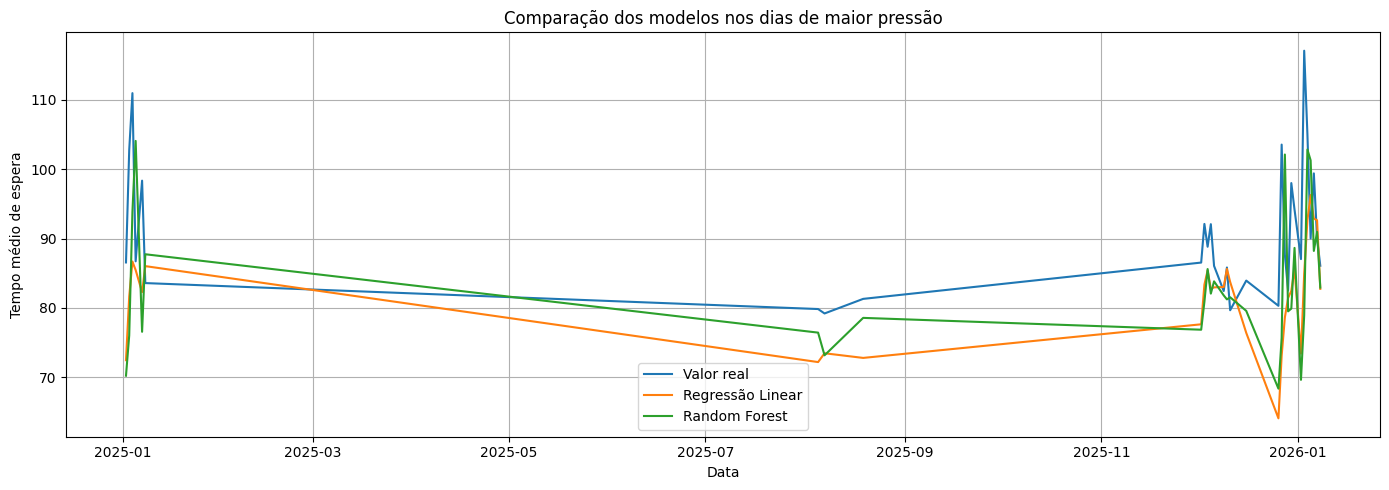

In [47]:
# Visualiza apenas os dias de pico: valor real vs previsões dos dois modelos
plt.figure(figsize=(14, 5))

plt.plot(
    df_picos["periodo"],
    df_picos[target],
    label="Valor real"
)

plt.plot(
    df_picos["periodo"],
    df_picos["previsao_regressao_linear"],
    label="Regressão Linear"
)

plt.plot(
    df_picos["periodo"],
    df_picos["previsao_random_forest"],
    label="Random Forest"
)

plt.title("Comparação dos modelos nos dias de maior pressão")
plt.xlabel("Data")
plt.ylabel("Tempo médio de espera")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Conclusão da comparação nos dias de maior pressão

A análise específica dos dias de maior pressão confirmou que a regressão linear manteve melhor desempenho do que o Random Forest.

Embora o Random Forest tenha apresentado menor erro em alguns dias de pico específicos, não conseguiu superar a regressão linear no conjunto dos dias de maior pressão. A regressão linear obteve menor MAE e menor RMSE tanto no teste global como no subconjunto de dias de pico.

Nos dias de maior pressão, a regressão linear teve menor erro absoluto em 18 dias, enquanto o Random Forest teve menor erro em 13 dias.

Estes resultados indicam que o Random Forest não acrescentou vantagem suficiente para ser considerado o melhor modelo nesta fase. Apesar da sua maior flexibilidade, o modelo não melhorou o desempenho global nem o comportamento nos extremos da série.

Assim, a regressão linear permanece como o melhor modelo candidato até ao momento.

## 13. Ridge Regression

Nesta etapa será testada uma versão regularizada da regressão linear: `Ridge Regression`.

A Ridge Regression é semelhante à regressão linear, mas aplica uma penalização aos coeficientes do modelo. Esta penalização ajuda a reduzir instabilidade quando existem variáveis explicativas muito correlacionadas entre si.

Neste projeto, essa situação é provável porque existem várias variáveis relacionadas com o histórico recente do tempo médio de espera, nomeadamente lags e médias móveis.

O objetivo é avaliar se uma regressão linear regularizada consegue melhorar ou estabilizar o desempenho face à regressão linear simples.

In [48]:
# Importa as ferramentas necessárias para Ridge Regression
from sklearn.linear_model import Ridge
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

# Define um pipeline com normalização e Ridge Regression
modelo_ridge_pipeline = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", Ridge())
])

# Define diferentes valores de alpha para testar
# Alpha controla a intensidade da regularização
parametros_ridge = {
    "model__alpha": [0.01, 0.1, 1, 10, 100]
}

# Define validação cruzada temporal
# Mantém a ordem cronológica dos dados durante a validação
tscv = TimeSeriesSplit(n_splits=5)

# Cria a pesquisa dos melhores parâmetros
grid_ridge = GridSearchCV(
    estimator=modelo_ridge_pipeline,
    param_grid=parametros_ridge,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    n_jobs=-1
)

# Treina a Ridge usando apenas o conjunto de treino
grid_ridge.fit(X_train, y_train)

# Mostra o melhor valor de alpha encontrado
print(f"Melhor alpha: {grid_ridge.best_params_['model__alpha']}")
print(f"Melhor MAE médio em validação temporal: {-grid_ridge.best_score_:.3f}")

Melhor alpha: 100
Melhor MAE médio em validação temporal: 4.363


In [49]:
# Usa o melhor modelo Ridge encontrado para prever no conjunto de teste
modelo_ridge = grid_ridge.best_estimator_

y_pred_ridge = modelo_ridge.predict(X_test)

# Calcula as métricas no conjunto de teste
mae_ridge, rmse_ridge = calcular_metricas(
    y_test,
    pd.Series(y_pred_ridge, index=y_test.index)
)

print(f"MAE Ridge Regression: {mae_ridge:.3f}")
print(f"RMSE Ridge Regression: {rmse_ridge:.3f}")

MAE Ridge Regression: 4.589
RMSE Ridge Regression: 6.254


In [50]:
# Cria uma tabela com o resultado da Ridge Regression
df_metricas_ridge = pd.DataFrame([
    {
        "modelo": "ridge_regression",
        "MAE": mae_ridge,
        "RMSE": rmse_ridge
    }
])

# Junta a Ridge à tabela de comparação dos modelos
df_comparacao_modelos = pd.concat(
    [
        df_comparacao_modelos,
        df_metricas_ridge
    ],
    ignore_index=True
)

# Remove duplicados caso a célula seja corrida mais do que uma vez
df_comparacao_modelos = (
    df_comparacao_modelos
    .drop_duplicates(subset=["modelo"], keep="last")
    .sort_values("MAE")
    .reset_index(drop=True)
)

df_comparacao_modelos

,modelo,MAE,RMSE
0,regressao_linear,4.430974,6.049873
1,ridge_regression,4.588860,6.254010
2,random_forest,4.654810,6.331863
3,baseline_media_7_dias,6.011422,7.856003
4,baseline_dia_anterior,6.234793,7.940093
5,baseline_semana_anterior,6.474657,9.030688


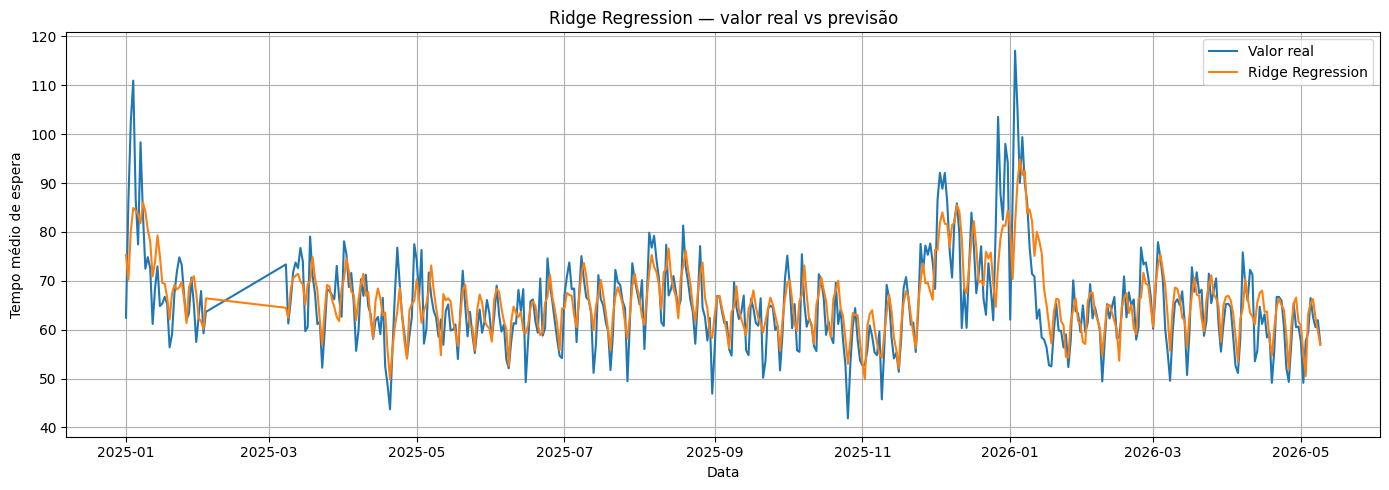

In [51]:
# Cria uma tabela com valores reais e previsões da Ridge Regression
df_resultados_ridge = df_test[["periodo", target]].copy()

df_resultados_ridge["previsao_ridge"] = y_pred_ridge

# Visualiza o valor real face à previsão da Ridge Regression
plt.figure(figsize=(14, 5))

plt.plot(
    df_resultados_ridge["periodo"],
    df_resultados_ridge[target],
    label="Valor real"
)

plt.plot(
    df_resultados_ridge["periodo"],
    df_resultados_ridge["previsao_ridge"],
    label="Ridge Regression"
)

plt.title("Ridge Regression — valor real vs previsão")
plt.xlabel("Data")
plt.ylabel("Tempo médio de espera")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [52]:
# Compara diretamente os erros absolutos da regressão linear e da Ridge
df_comparacao_lr_ridge = df_test[["periodo", target]].copy()

df_comparacao_lr_ridge["erro_abs_regressao_linear"] = (
    df_comparacao_lr_ridge[target] - y_pred_lr
).abs()

df_comparacao_lr_ridge["erro_abs_ridge"] = (
    df_comparacao_lr_ridge[target] - y_pred_ridge
).abs()

df_comparacao_lr_ridge["diferenca_erro_ridge_vs_lr"] = (
    df_comparacao_lr_ridge["erro_abs_ridge"] -
    df_comparacao_lr_ridge["erro_abs_regressao_linear"]
)

dias_lr_melhor_ridge = (
    df_comparacao_lr_ridge["erro_abs_regressao_linear"] <
    df_comparacao_lr_ridge["erro_abs_ridge"]
).sum()

dias_ridge_melhor = (
    df_comparacao_lr_ridge["erro_abs_ridge"] <
    df_comparacao_lr_ridge["erro_abs_regressao_linear"]
).sum()

dias_empate_lr_ridge = (
    df_comparacao_lr_ridge["erro_abs_regressao_linear"] ==
    df_comparacao_lr_ridge["erro_abs_ridge"]
).sum()

print(f"Dias em que a regressão linear teve menor erro: {dias_lr_melhor_ridge}")
print(f"Dias em que a Ridge teve menor erro: {dias_ridge_melhor}")
print(f"Dias com empate: {dias_empate_lr_ridge}")

Dias em que a regressão linear teve menor erro: 265
Dias em que a Ridge teve menor erro: 197
Dias com empate: 0


### Interpretação da Ridge Regression

A Ridge Regression apresentou melhor desempenho do que os modelos baseline e do que o Random Forest, mas não superou a regressão linear simples no conjunto de teste.

Apesar de a validação cruzada temporal ter selecionado `alpha = 100`, indicando benefício da regularização dentro do conjunto de treino, o desempenho no período de teste foi inferior ao da regressão linear.

A regressão linear apresentou menor MAE, menor RMSE e teve menor erro absoluto em mais dias do conjunto de teste.

Este resultado sugere que, embora exista correlação entre várias variáveis explicativas, a regularização aplicada pela Ridge não acrescentou vantagem preditiva suficiente no período mais recente. Assim, a Ridge Regression fica como modelo comparativo, mas não substitui a regressão linear como melhor modelo candidato.

## 14. Seleção do melhor modelo

Após a avaliação dos modelos baseline, regressão linear, Random Forest e Ridge Regression, será selecionado o melhor modelo com base no desempenho no conjunto de teste.

O principal critério de seleção será o MAE, por representar o erro médio absoluto em minutos, uma métrica fácil de interpretar no contexto do tempo médio de espera.

O RMSE será usado como métrica complementar, por penalizar mais os erros elevados.

In [53]:
# Identifica o melhor baseline com base no MAE
melhor_baseline = df_metricas_baseline.sort_values("MAE").iloc[0]

mae_melhor_baseline = melhor_baseline["MAE"]
rmse_melhor_baseline = melhor_baseline["RMSE"]

print(f"Melhor baseline: {melhor_baseline['modelo']}")
print(f"MAE melhor baseline: {mae_melhor_baseline:.3f}")
print(f"RMSE melhor baseline: {rmse_melhor_baseline:.3f}")

Melhor baseline: baseline_media_7_dias
MAE melhor baseline: 6.011
RMSE melhor baseline: 7.856


In [54]:
# Cria uma tabela final de comparação com melhoria face ao melhor baseline
df_comparacao_final = df_comparacao_modelos.copy()

df_comparacao_final["melhoria_MAE_vs_melhor_baseline_%"] = (
    (mae_melhor_baseline - df_comparacao_final["MAE"]) /
    mae_melhor_baseline *
    100
)

df_comparacao_final["melhoria_RMSE_vs_melhor_baseline_%"] = (
    (rmse_melhor_baseline - df_comparacao_final["RMSE"]) /
    rmse_melhor_baseline *
    100
)

df_comparacao_final = df_comparacao_final.sort_values("MAE").reset_index(drop=True)

df_comparacao_final

,modelo,MAE,RMSE,melhoria_MAE_vs_melhor_baseline_%,melhoria_RMSE_vs_melhor_baseline_%
0,regressao_linear,4.430974,6.049873,26.290760,22.990443
1,ridge_regression,4.588860,6.254010,23.664313,20.391960
2,random_forest,4.654810,6.331863,22.567246,19.400963
3,baseline_media_7_dias,6.011422,7.856003,0.000000,0.000000
4,baseline_dia_anterior,6.234793,7.940093,-3.715773,-1.070384
5,baseline_semana_anterior,6.474657,9.030688,-7.705915,-14.952702


In [55]:
# Seleciona o melhor modelo com base no menor MAE
melhor_modelo = df_comparacao_final.iloc[0]

print(f"Melhor modelo: {melhor_modelo['modelo']}")
print(f"MAE: {melhor_modelo['MAE']:.3f} minutos")
print(f"RMSE: {melhor_modelo['RMSE']:.3f} minutos")
print(f"Melhoria no MAE face ao melhor baseline: {melhor_modelo['melhoria_MAE_vs_melhor_baseline_%']:.1f}%")
print(f"Melhoria no RMSE face ao melhor baseline: {melhor_modelo['melhoria_RMSE_vs_melhor_baseline_%']:.1f}%")

Melhor modelo: regressao_linear
MAE: 4.431 minutos
RMSE: 6.050 minutos
Melhoria no MAE face ao melhor baseline: 26.3%
Melhoria no RMSE face ao melhor baseline: 23.0%


In [56]:
# Como a regressão linear foi o melhor modelo, cria-se a tabela final de previsões
df_previsoes_modelo_final = df_test[["periodo", target]].copy()

df_previsoes_modelo_final["previsao_modelo_final"] = y_pred_lr

df_previsoes_modelo_final["erro"] = (
    df_previsoes_modelo_final[target] -
    df_previsoes_modelo_final["previsao_modelo_final"]
)

df_previsoes_modelo_final["erro_absoluto"] = (
    df_previsoes_modelo_final["erro"].abs()
)

df_previsoes_modelo_final.head()

,periodo,tempo_medio_espera,previsao_modelo_final,erro,erro_absoluto
2955,2025-01-01,62.4545,76.453489,-13.998989,13.998989
2956,2025-01-02,86.5522,72.469265,14.082935,14.082935
2957,2025-01-03,102.7310,81.627606,21.103394,21.103394
2958,2025-01-04,110.9420,86.680724,24.261276,24.261276
2959,2025-01-05,86.7138,85.455223,1.258577,1.258577


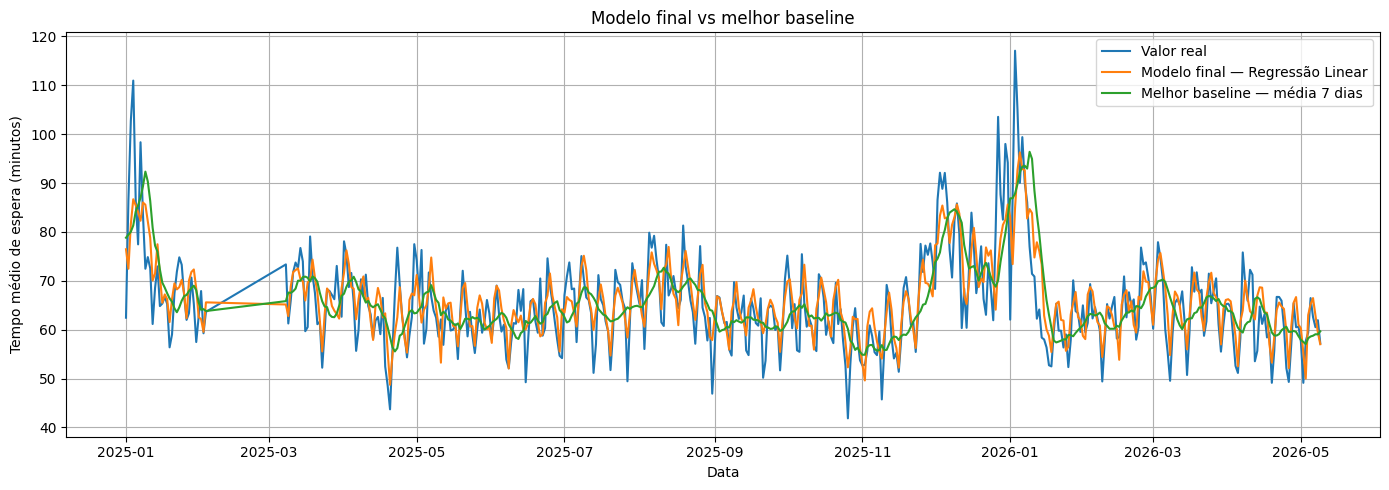

In [57]:
# Compara o valor real, o melhor baseline e o modelo final
plt.figure(figsize=(14, 5))

plt.plot(
    df_test["periodo"],
    y_test,
    label="Valor real"
)

plt.plot(
    df_test["periodo"],
    y_pred_lr,
    label="Modelo final — Regressão Linear"
)

plt.plot(
    df_baseline["periodo"],
    df_baseline["baseline_media_7_dias"],
    label="Melhor baseline — média 7 dias"
)

plt.title("Modelo final vs melhor baseline")
plt.xlabel("Data")
plt.ylabel("Tempo médio de espera (minutos)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 15. Interpretação do modelo final

Após a seleção da regressão linear como melhor modelo, é relevante analisar os coeficientes do modelo.

Como a regressão linear foi treinada dentro de um pipeline com `StandardScaler`, os coeficientes refletem o efeito relativo de cada variável após normalização.

Esta análise permite perceber quais as variáveis mais associadas à previsão do tempo médio de espera.

In [58]:
# Extrai o modelo de regressão linear de dentro do pipeline
modelo_linear_final = modelo_regressao_linear.named_steps["model"]

# Cria uma tabela com os coeficientes do modelo
df_coeficientes_lr = pd.DataFrame({
    "feature": features,
    "coeficiente": modelo_linear_final.coef_
})

# Calcula o valor absoluto dos coeficientes para ordenar por importância relativa
df_coeficientes_lr["coeficiente_absoluto"] = df_coeficientes_lr["coeficiente"].abs()

# Ordena as variáveis por magnitude do coeficiente
df_coeficientes_lr = (
    df_coeficientes_lr
    .sort_values("coeficiente_absoluto", ascending=False)
    .reset_index(drop=True)
)

df_coeficientes_lr.head(15)

,feature,coeficiente,coeficiente_absoluto
0,tempo_medio_espera_media_movel_7,8.960550,8.960550
1,tempo_medio_espera_media_movel_14,-6.266527,6.266527
2,tempo_medio_espera_lag_1,5.292058,5.292058
3,mes,-3.111095,3.111095
4,dia_do_ano,2.815642,2.815642
5,dia_semana,-2.795357,2.795357
6,tempo_medio_espera_lag_14,1.959804,1.959804
7,tempo_medio_espera_media_movel_28,1.739001,1.739001
8,taxa_internamento_lag_7,1.471986,1.471986
9,taxa_internamento_lag_1,-1.164706,1.164706


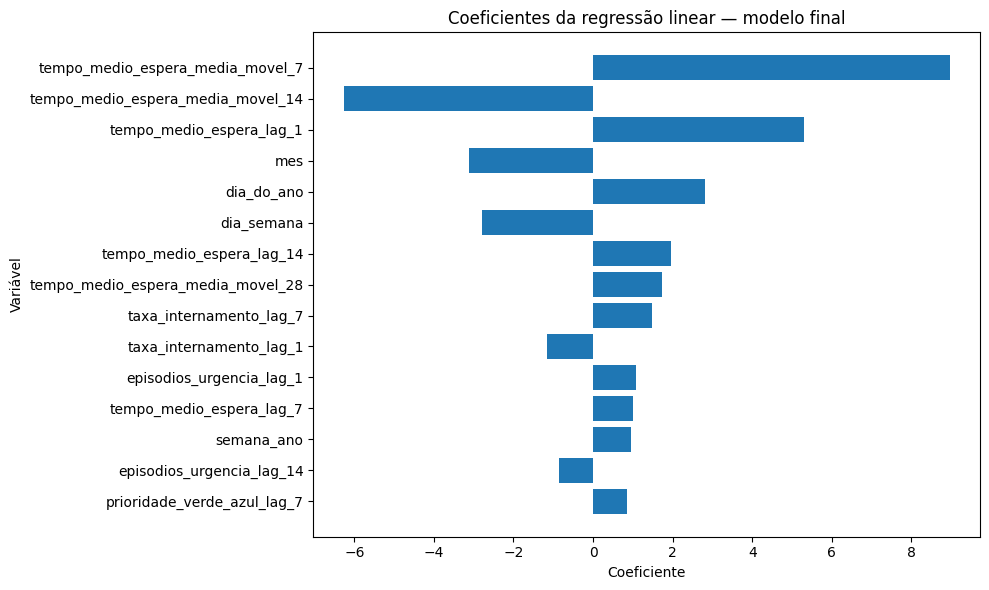

In [59]:
# Visualiza os 15 coeficientes mais relevantes em valor absoluto
top_coeficientes_lr = df_coeficientes_lr.head(15).sort_values("coeficiente_absoluto")

plt.figure(figsize=(10, 6))

plt.barh(
    top_coeficientes_lr["feature"],
    top_coeficientes_lr["coeficiente"]
)

plt.title("Coeficientes da regressão linear — modelo final")
plt.xlabel("Coeficiente")
plt.ylabel("Variável")
plt.tight_layout()
plt.show()

### Interpretação dos coeficientes do modelo final

A análise dos coeficientes da regressão linear mostra que as variáveis com maior influência relativa estão sobretudo relacionadas com o histórico recente do próprio tempo médio de espera.

A variável com maior coeficiente absoluto foi a média móvel dos 7 dias anteriores, seguida da média móvel dos 14 dias anteriores e do valor observado no dia anterior. Este resultado indica que o modelo depende principalmente da memória recente da série temporal para prever o tempo médio de espera.

Também surgem variáveis de calendário, como o mês, o dia do ano e o dia da semana, sugerindo que o modelo incorpora algum padrão temporal ou sazonal na previsão.

A interpretação dos coeficientes deve, no entanto, ser feita com cautela. Várias variáveis explicativas estão fortemente relacionadas entre si, especialmente os lags e as médias móveis do tempo médio de espera. Por esse motivo, o sinal positivo ou negativo de um coeficiente não deve ser interpretado como uma relação causal direta.

Em termos gerais, os coeficientes confirmam que o modelo final se baseia sobretudo no comportamento recente do tempo médio de espera, complementado por variáveis de calendário e por indicadores operacionais históricos.

## 16. Conclusão final

Este projeto desenvolveu uma primeira abordagem preditiva para estimar o tempo médio diário de espera entre a triagem e a primeira observação médica na rede de urgência hospitalar do SNS em Portugal Continental.

A modelação foi realizada com base na série nacional previamente preparada no Projeto 1, respeitando a ordem temporal dos dados e evitando fuga de informação. Para isso, foram utilizadas apenas variáveis de calendário e variáveis históricas, como lags e médias móveis.

Foram avaliados modelos baseline e modelos supervisionados de regressão. O melhor baseline foi a média móvel dos 7 dias anteriores, com um MAE de aproximadamente 6,0 minutos.

Entre os modelos de Machine Learning testados, a regressão linear apresentou o melhor desempenho, com um MAE de 4,43 minutos e um RMSE de 6,05 minutos no conjunto de teste. Este resultado representa uma melhoria de 26,3% no MAE face ao melhor baseline.

O Random Forest e a Ridge Regression também superaram os baselines, mas não melhoraram o desempenho da regressão linear. A análise dos dias de maior pressão confirmou que a regressão linear manteve melhor desempenho global e também melhor desempenho nos dias de pico.

Assim, nesta fase, a regressão linear foi selecionada como melhor modelo candidato.

Apesar dos resultados positivos, o modelo apresenta limitações. A principal limitação é a dificuldade em prever picos abruptos do tempo médio de espera. Esta limitação é relevante porque os dias de maior pressão são precisamente os mais importantes do ponto de vista operacional.

Este projeto deve ser interpretado como uma primeira prova de conceito preditiva, e não como uma ferramenta final de apoio à decisão. Futuras iterações poderiam incluir novas variáveis explicativas, validação temporal adicional, modelos específicos para deteção de picos e análise regional.

## 17. Exportação dos resultados

Para facilitar a consulta posterior dos resultados do Projeto 2, serão exportadas as principais tabelas produzidas no notebook.

Serão guardadas as tabelas de comparação dos modelos, previsões do modelo final, coeficientes da regressão linear e métricas específicas dos dias de maior pressão.

In [60]:
# Define a pasta onde serão guardadas as tabelas do Projeto 2
OUTPUT_TABLES = Path("../reports/tables")
OUTPUT_TABLES.mkdir(parents=True, exist_ok=True)

# Organiza as principais tabelas a exportar
tabelas_para_exportar = {
    "projeto2_comparacao_modelos.csv": df_comparacao_final,
    "projeto2_previsoes_modelo_final.csv": df_previsoes_modelo_final,
    "projeto2_coeficientes_regressao_linear.csv": df_coeficientes_lr,
    "projeto2_metricas_dias_pico.csv": df_metricas_picos
}

# Exporta as tabelas em formato CSV
for nome_ficheiro, tabela in tabelas_para_exportar.items():
    caminho_ficheiro = OUTPUT_TABLES / nome_ficheiro
    tabela.to_csv(caminho_ficheiro, sep=";", index=False, decimal=",")
    print(f"Exportado: {caminho_ficheiro}")

Exportado: ..\reports\tables\projeto2_comparacao_modelos.csv
Exportado: ..\reports\tables\projeto2_previsoes_modelo_final.csv
Exportado: ..\reports\tables\projeto2_coeficientes_regressao_linear.csv
Exportado: ..\reports\tables\projeto2_metricas_dias_pico.csv


In [61]:
# Validação final dos principais resultados do Projeto 2
print("Comparação final dos modelos:")
display(df_comparacao_final)

print("\nMelhor modelo selecionado:")
print(f"Modelo: {melhor_modelo['modelo']}")
print(f"MAE: {melhor_modelo['MAE']:.3f} minutos")
print(f"RMSE: {melhor_modelo['RMSE']:.3f} minutos")
print(f"Melhoria MAE vs melhor baseline: {melhor_modelo['melhoria_MAE_vs_melhor_baseline_%']:.1f}%")
print(f"Melhoria RMSE vs melhor baseline: {melhor_modelo['melhoria_RMSE_vs_melhor_baseline_%']:.1f}%")

Comparação final dos modelos:


,modelo,MAE,RMSE,melhoria_MAE_vs_melhor_baseline_%,melhoria_RMSE_vs_melhor_baseline_%
0,regressao_linear,4.430974,6.049873,26.290760,22.990443
1,ridge_regression,4.588860,6.254010,23.664313,20.391960
2,random_forest,4.654810,6.331863,22.567246,19.400963
3,baseline_media_7_dias,6.011422,7.856003,0.000000,0.000000
4,baseline_dia_anterior,6.234793,7.940093,-3.715773,-1.070384
5,baseline_semana_anterior,6.474657,9.030688,-7.705915,-14.952702



Melhor modelo selecionado:
Modelo: regressao_linear
MAE: 4.431 minutos
RMSE: 6.050 minutos
Melhoria MAE vs melhor baseline: 26.3%
Melhoria RMSE vs melhor baseline: 23.0%
